# E3SM-FOSIRL, E3SM-Reanalysis, and CESM-SMYLE Seasonal Modes-of-Variability Analysis

Analyze the official PMP extra-tropical modes (`NAM`, `NAO`, `SAM`, `PNA`,
`NPO`, `PDO`, and `NPGO`) and the ESP-Lab extensions (`EA`, `SCA`, and
`AMO`). Set `selected_mode` in the control panel. NAO includes station-
and EOF-based skill; all other modes use the common-basis EOF index.

This revised notebook keeps the scientific workflow in the notebook and uses
one helper module, `esp_lab.utils.mov_utils`, for reusable MOV map, plotting,
I/O, and skill-metric utilities.


In [49]:
from esp_lab.paths import (
    S2D_DIAG_ROOT,
    E3SMLE_DIAG_DIR,
    CESM_SMYLE_DIAG_DIR,
    NMME_DIAG_DIR,
    MODES_VARIABILITY_DIAG_DIR,
)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import os
import re
import uuid
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from esp_lab import stats
from esp_lab.utils import mov_utils as mov

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
print("xarray:", xr.__version__)
print("map utilities:", getattr(mov, "__file__", "module object"))
print("cartopy available:", mov.has_cartopy())


xarray: 2026.4.0
map utilities: /global/u2/z/zhan391/code/ESP-Lab/esp_lab/utils/mov_utils.py
cartopy available: True


## User Control Panel


In [51]:
# -----------------------------------------------------------------------------
# Directory setup
# -----------------------------------------------------------------------------
# Override the root for a different workspace with ESP_LAB_S2D_DIAG_ROOT.
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR

# Select one mode produced by 0_run_sigmod_emov.ipynb.

from pathlib import Path
import numpy as np

official_pmp_modes = ("NAM", "NAO", "SAM", "PNA", "NPO", "PDO", "NPGO")
extension_modes = ("EA", "SCA", "AMO", "PSA1", "PSA2")
supported_modes = official_pmp_modes + extension_modes

#selected_mode = "NAM" #"SAM" #"PSA2" #"PSA1"
selected_mode = "SCA" #"NAO" # "EA" # "SCA" #"AMO" 
selected_mode = selected_mode.upper().strip()

if selected_mode not in supported_modes:
    raise ValueError(
        f"selected_mode must be one of {supported_modes}, got {selected_mode!r}"
    )

FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

analysis_outdir = MODES_OUTDIR
manifest_file = analysis_outdir / "_manifests" / "modes_manifest.json"
legacy_manifest_file = analysis_outdir / "modes_manifest.json"
if not manifest_file.exists() and legacy_manifest_file.exists():
    manifest_file = legacy_manifest_file
index_cache_dir = analysis_outdir / "modes" / selected_mode.lower() / "indices"
# Tables below combine several forecast sources, so keep them outside any
# individual source directory and give them an explicit multi-model owner.
multimodel_analysis_outdir = analysis_outdir / "multimodel" / "modes_variability"
table_outdir = multimodel_analysis_outdir / "tables"

# Analysis labels map to the cache tags written by 0_run_sigmod_emov.ipynb.
# NMME is optional because not every mode/init combination is always processed.
include_nmme = False
core_model_product_tags = {
    "E3SM-FOSIRL": "JRA55_FOSIRL",
    "E3SM-Reanalysis": "Reanalysis",
    "SMYLE": "smyle",
}
optional_model_product_tags = {"NMME": "nmme"}
model_product_tags = dict(core_model_product_tags)
model_source_dirs = {
    "E3SM-FOSIRL": "JRA55_FOSIRL",
    "E3SM-Reanalysis": "Reanalysis",
    "SMYLE": "CESM-SMYLE",
    "NMME": "NMME",
}
model_expected_sources = {
    "E3SM-FOSIRL": "E3SM",
    "E3SM-Reanalysis": "E3SM",
    "SMYLE": "SMYLE",
    "NMME": "NMME",
}
model_display_names = {
    "E3SM-FOSIRL": "E3SMv3-FOSIRL",
    "E3SM-Reanalysis": "E3SMv3-Reanalysis",
    "SMYLE": "CESM-SMYLE",
    "NMME": "NMME",
}
models = tuple(model_product_tags)
init_months = [5, 11]

climy0 = 1981
climy1 = 2010
seasonal_nlead = 7
skill_lead_axis = "seasonal_target_months"
skill_detrend = True
force_recompute_skill = True
write_summary_tables = True

analysis_methods = ["eof"]
if selected_mode == "NAO":
    analysis_methods = ["station", "eof"]


# ---------------------------------------------------------------------
# Mode-aware EOF-pattern map configuration
# ---------------------------------------------------------------------
# label_strategy:
#   "cartopy" : normal Cartopy longitude/latitude labels
#   "pacific" : manual Pacific labels, e.g., 120E, 150E, 180, 150W
#   "polar"   : polar-style labels; no regular Cartopy x/y labels
# ---------------------------------------------------------------------

BASE_EOF_PATTERN_SETTINGS = {
    # General figure layout
    "figsize_width": 14.5,
    "figsize_row_height": 2.75,
    "pattern_years": (1, 2),
    "pattern_seasons": ("DJF", "MAM", "JJA", "SON"),
    "preferred_init_by_season": {
        "DJF": 11,
        "MAM": 11,
        "JJA": 5,
        "SON": 5,
    },

    # Main title / column headers / panel titles
    "suptitle_scale": 1.00,
    "column_header_scale": 0.95,
    "panel_title_scale": 0.72,
    "panel_title_pad": 3,
    "panel_title_linespacing": 1.10,
    "year_section_title_scale": 1.00,
    # "panel_title_loc": "left",  # Optional: override panel title location (e.g. 'left', 'center', 'right')
    # "panel_title_x": 0.5,       # Optional: override panel title x position
    # "panel_title_y": 1.0,       # Optional: override panel title y position
    # "panel_title_ha": "center", # Optional: override panel title horizontal alignment
    # "year_title_y": 0.98,       # Optional: override subfigure year/section title y position
    # "year_title_linespacing": 1.05,  # Optional: override subfigure year/section title linespacing

    # Metric box
    "rmse_decimals": 2,
    "pcc_decimals": 2,
    "metric_box_x": 0.03,
    "metric_box_y": 0.045,
    "metric_box_font_scale": 0.62,
    "metric_box_alpha": 0.5,
    "metric_box_pad": 0.16,
    "metric_box_linewidth": 0.45,
    "metric_box_zorder": 10,

    # Axis/colorbar labels
    "axis_label_scale": 0.90,
    "tick_label_scale": 0.58,
    "colorbar_label_scale": 0.78,
    "colorbar_tick_scale": 0.66,
    "colorbar_shrink": 0.80,
    "colorbar_pad": 0.035,
    "colorbar_fraction": 0.030,

    # Stippling
    "stipple_stride": 2,
    "stipple_size": 9,
    "stipple_color": "black",
    "stipple_alpha": 0.50,
    "stipple_zorder": 4,

    # Filled contours and contour lines
    "levels": np.arange(-3.0, 3.01, 0.5),
    "draw_contour_lines": True,
    "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    "contour_line_color": "0.20",
    "contour_linewidth": 0.45,
    "contour_line_alpha": 0.70,

    # Gridline style
    "grid_alpha": 0.45,
    "grid_linewidth": 0.8,
    "grid_linestyle": "--",
    "grid_color": "0.55",
    "grid_rotate_labels": False,

    # Label visibility defaults
    "label_strategy": "cartopy",
    "map_draw_labels": True,
    "map_label_scale": 0.55,
    "draw_left_labels": True,
    "draw_bottom_labels": True,
    "draw_top_labels": False,
    "draw_right_labels": False,
    "label_left_column_only": True,
    "label_bottom_row_only": True,

    # Default tick locations
    "longitude_ticks": np.arange(-180, 181, 30),
    "latitude_ticks": np.arange(-90, 91, 20),
    "longitude_ticklabels": None,
    "latitude_ticklabels": None,

    # Manual label offsets for projected maps
    "manual_lon_label_offset": 1.5,
    "manual_lat_label_offset": 1.5,

    # Polar-map behavior
    "polar_circular_boundary": True,
    "polar_draw_regular_labels": False,
    "polar_longitude_label_offset": 2.5,
    "polar_longitude_ticks": np.arange(-180, 181, 60),

    # Section spacing
    "top_section_gap_ratio": 0.015,
    "year_section_header_ratio": 0.58,
    "year_section_gap_ratio": 0.16,

    # Subplot layout
    "subplot_left": 0.070,
    "subplot_right": 0.965,
    "subplot_bottom": 0.145,
    "subplot_top": 0.890,
    "subplot_wspace": 0.080,
    "subplot_hspace": 0.300,

    # Map features
    "use_cartopy": True,
    "coastline_linewidth": 0.45,
    "global_land_facecolor": "0.18",
    "global_land_edgecolor": "0.05",
    "global_land_linewidth": 0.25,
    "global_land_zorder": 4,
    "global_coastline_color": "0.05",
    "global_coastline_linewidth": 0.35,
    "global_coastline_zorder": 5,
}


MODE_LAYOUT_CONFIG = {
    "NAM": {
        "figsize_width": 12.0,
        "figsize_row_height": 5.0,
        "subplot_left": 0.055,
        "subplot_right": 0.845,
        "subplot_bottom": 0.170,
        "subplot_top": 0.855,
        "subplot_wspace": 0.80,
        "subplot_hspace": 0.30,
        "year_section_header_ratio": 0.20,
        "map_label_scale": 0.70,
        "metric_box_font_scale": 0.58,
        "polar_metric_box_x": 0.90,
        "polar_metric_box_y": 0.020,
        "polar_metric_box_ha": "center",
        "polar_metric_box_va": "center",
        "polar_metric_two_lines": True,
        "colorbar_pad": 0.080,
        "colorbar_fraction": 0.026,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "year_title_y_ratio": 0.76,
        "column_title_y_ratio": 0.12,
        "panel_title_pad": 0,
        "panel_title_y": 1.03,
        "column_header_shift_by_col": {1: -0.035, 2: -0.06},
        "column_header_y_shift_by_col": {0: 0.0, 1: 0.0, 2: 0.0},
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "SAM": {
        "figsize_width": 12.0,
        "figsize_row_height": 5.0,
        "subplot_left": 0.055,
        "subplot_right": 0.845,
        "subplot_bottom": 0.170,
        "subplot_top": 0.855,
        "subplot_wspace": 0.80,
        "subplot_hspace": 0.30,
        "year_section_header_ratio": 0.20,
        "map_label_scale": 0.70,
        "metric_box_font_scale": 0.58,
        "polar_metric_box_x": 0.90,
        "polar_metric_box_y": 0.020,
        "polar_metric_box_ha": "center",
        "polar_metric_box_va": "center",
        "polar_metric_two_lines": True,
        "colorbar_pad": 0.080,
        "colorbar_fraction": 0.026,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "year_title_y_ratio": 0.76,
        "column_title_y_ratio": 0.12,
        "panel_title_pad": 0,
        "panel_title_y": 1.03,
        "column_header_shift_by_col": {1: -0.035, 2: -0.06},
        "column_header_y_shift_by_col": {0: 0.0, 1: 0.0, 2: 0.0},
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "NAO": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.2,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.05,
        "subplot_hspace": 0.40,
        "year_section_title_scale": 0.82,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.52,
        "metric_box_font_scale": 0.48,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.58,
        "suptitle_scale": 0.82,
        "column_header_scale": 0.70,
        "panel_title_pad": 5,
        "panel_title_y": 1.02,
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "EA": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.2,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.05,
        "subplot_hspace": 0.40,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 8,
        "panel_title_y": 1.02,
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "SCA": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.2,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.05,
        "subplot_hspace": 0.40,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 8,
        "panel_title_y": 1.02,
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "PNA": {
        "figsize_width": 14.8,
        "figsize_row_height": 2.75,
        "subplot_left": 0.082,
        "subplot_right": 0.965,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.090,
        "subplot_hspace": 0.300,
        "map_label_scale": 0.5,
    },
    "NPO": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.50,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.08,
        "subplot_hspace": 0.22,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 0,
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "NPGO": {
        "figsize_width": 10.0,
        "figsize_row_height": 2.50,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.08,
        "subplot_hspace": 0.22,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 0,
        "levels": np.arange(-1.0, 1.01, 0.2),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-1.0, 1.01, 0.2),    },
    "PDO": {
        "figsize_width": 12.0,
        "figsize_row_height": 3.00,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.04,
        "subplot_hspace": 0.30,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 8,
        "panel_title_y": 1.02,
        "levels": np.arange(-1.0, 1.01, 0.2),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-1.0, 1.01, 0.2),
    },
    "AMO": {
        "figsize_width": 12.0,
        "figsize_row_height": 4.00,
        "subplot_left": 0.08,
        "subplot_right": 0.94,
        "subplot_bottom": 0.150,
        "subplot_top": 0.890,
        "subplot_wspace": 0.04,
        "subplot_hspace": 0.30,
        "year_section_title_scale": 0.90,
        "year_section_header_ratio": 0.55,
        "panel_title_scale": 0.70,
        "colorbar_pad": 0.015,
        "map_label_scale": 0.75,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "panel_title_pad": 4,
        "panel_title_y": 1.0,
        "levels": np.arange(-1.0, 1.01, 0.2),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-1.0, 1.01, 0.2),
    },
    "PSA1": {
        "figsize_width": 12.0,
        "figsize_row_height": 5.0,
        "subplot_left": 0.055,
        "subplot_right": 0.845,
        "subplot_bottom": 0.170,
        "subplot_top": 0.855,
        "subplot_wspace": 0.80,
        "subplot_hspace": 0.30,
        "year_section_header_ratio": 0.20,
        "map_label_scale": 0.70,
        "metric_box_font_scale": 0.58,
        "polar_metric_box_x": 0.90,
        "polar_metric_box_y": 0.020,
        "polar_metric_box_ha": "center",
        "polar_metric_box_va": "center",
        "polar_metric_two_lines": True,
        "colorbar_pad": 0.080,
        "colorbar_fraction": 0.026,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "year_title_y_ratio": 0.76,
        "column_title_y_ratio": 0.12,
        "panel_title_pad": 0,
        "panel_title_y": 1.03,
        "column_header_shift_by_col": {
            1: -0.035, 2: -0.06, 3: -0.075, 4: -0.11
        },
        "column_header_y_shift_by_col": {
            0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0
        },
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
    "PSA2": {
        "figsize_width": 12.0,
        "figsize_row_height": 5.0,
        "subplot_left": 0.055,
        "subplot_right": 0.845,
        "subplot_bottom": 0.170,
        "subplot_top": 0.855,
        "subplot_wspace": 0.80,
        "subplot_hspace": 0.30,
        "year_section_header_ratio": 0.20,
        "map_label_scale": 0.70,
        "metric_box_font_scale": 0.58,
        "polar_metric_box_x": 0.90,
        "polar_metric_box_y": 0.020,
        "polar_metric_box_ha": "center",
        "polar_metric_box_va": "center",
        "polar_metric_two_lines": True,
        "colorbar_pad": 0.080,
        "colorbar_fraction": 0.026,
        "suptitle_scale": 0.9,
        "column_header_scale": 0.85,
        "year_title_y_ratio": 0.76,
        "column_title_y_ratio": 0.12,
        "panel_title_pad": 0,
        "panel_title_y": 1.03,
        "column_header_shift_by_col": {
            1: -0.035, 2: -0.06, 3: -0.075, 4: -0.11
        },
        "column_header_y_shift_by_col": {
            0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0
        },
        "levels": np.arange(-3.0, 3.01, 0.5),
        "draw_contour_lines": True,
        "contour_line_levels": np.arange(-3.0, 3.01, 0.5),
    },
}

# Keep the four polar-mode figure layouts synchronized. Their geographic
# projections and labels remain mode-specific in MODE_MAP_LABEL_CONFIG.
for polar_mode in ("NAM", "SAM", "PSA2"):
    MODE_LAYOUT_CONFIG[polar_mode] = dict(MODE_LAYOUT_CONFIG["PSA1"])

# Use one compact layout profile for modes drawn with the Atlantic
# Albers projection. Keep their mode-specific geometry and contour levels.
ATLANTIC_EOF_LAYOUT_REFINEMENTS = {
    "subplot_hspace": 0.18,
    "year_section_header_ratio": 0.42,
    "year_section_title_scale": 0.70,
    "panel_title_scale": 0.44,
    "metric_box_font_scale": 0.48,
    "map_label_scale": 0.58,
    "suptitle_scale": 0.82,
    "column_header_scale": 0.60,
    "panel_title_pad": 5,
}
for atlantic_mode in ("NAO", "EA", "SCA", "AMO"):
    MODE_LAYOUT_CONFIG[atlantic_mode].update(ATLANTIC_EOF_LAYOUT_REFINEMENTS)


PACIFIC_LONGITUDE_TICKS = np.array([120, 150, 180, -150, -120])
PACIFIC_LONGITUDE_LABELS = ["120°E", "150°E", "180°", "150°W", "120°W"]
NORTH_PACIFIC_LATITUDE_TICKS = np.array([10, 20, 30, 40, 50, 60, 70])
NORTH_PACIFIC_LATITUDE_LABELS = ["10°N", "20°N", "30°N", "40°N", "50°N", "60°N", "70°N"]

ATLANTIC_LONGITUDE_TICKS = np.array([-90, -60, -30, 0, 30])
ATLANTIC_LATITUDE_TICKS = np.array([20, 30, 40, 50, 60, 70, 80])

SOUTH_PACIFIC_LONGITUDE_TICKS = np.array([120, 150, 180, -150, -120, -90, -60])
SOUTH_PACIFIC_LATITUDE_TICKS = np.array([-80, -70, -60, -50, -40, -30, -20])
PSA2_LONGITUDE_TICKS = np.array([180, -150, -120, -90, -60, -30, 0])

GLOBAL_LONGITUDE_TICKS = np.arange(-180, 181, 60)
GLOBAL_LATITUDE_TICKS = np.arange(-60, 61, 30)

ALBERS_PROJECTION_BY_MODE = {
    "NAO":  {"central_longitude": -30,  "central_latitude": 50, "standard_parallels": (30, 70)},
    "EA":   {"central_longitude": -20,  "central_latitude": 50, "standard_parallels": (30, 70)},
    "SCA":  {"central_longitude": -20,  "central_latitude": 50, "standard_parallels": (35, 70)},
    "NPO":  {"central_longitude": 180,  "central_latitude": 40, "standard_parallels": (20, 60)},
    "NPGO": {"central_longitude": 180,  "central_latitude": 45, "standard_parallels": (20, 60)},
    "PSA1": {"central_longitude": 0},
    "PSA2": {"central_longitude": 0},
}

MODE_MAP_LABEL_CONFIG = {
    "NAM": {
        "label_strategy": "polar",
        "longitude_ticks": np.arange(-180, 181, 60),
        "latitude_ticks": np.array([25, 55, 85]),
        "polar_longitude_ticks": np.array([-120, -60, 60, 120]),
        "polar_longitude_skip": [],
        "polar_longitude_label_position": "outside_axes",
        "polar_longitude_label_radius": 0.625,
        "polar_central_longitude": 0,
        "polar_latitude_ticks": np.array([25, 55, 85]),
        "polar_latitude_label_position": "radial",
        "polar_latitude_label_angle": -20,
        "polar_longitude_labels_each_panel": True,
        "polar_latitude_labels_each_panel": True,
        "draw_polar_latitude_labels": True,
        "draw_left_labels": False,
        "draw_bottom_labels": False,
        "polar_draw_regular_labels": False,
        "polar_longitude_label_offset": 2.5,
        "polar_label_color": "0.25",
        "map_label_scale": 0.70,
        "grid_rotate_labels": False,
    },
    "SAM": {
        "label_strategy": "polar",
        "longitude_ticks": np.arange(-180, 181, 60),
        "latitude_ticks": np.array([-85, -55, -25]),
        "polar_longitude_ticks": np.array([-120, -60, 60, 120]),
        "polar_longitude_skip": [],
        "polar_longitude_label_position": "outside_axes",
        "polar_longitude_label_radius": 0.625,
        "polar_central_longitude": 0,
        "polar_latitude_ticks": np.array([-85, -55, -25]),
        "polar_latitude_label_position": "radial",
        "polar_latitude_label_angle": -20,
        "polar_longitude_labels_each_panel": True,
        "polar_latitude_labels_each_panel": True,
        "draw_polar_latitude_labels": True,
        "draw_left_labels": False,
        "draw_bottom_labels": False,
        "polar_draw_regular_labels": False,
        "polar_longitude_label_offset": 2.5,
        "polar_label_color": "0.25",
        "map_label_scale": 0.70,
        "grid_rotate_labels": False,
    },
    "NAO": {
        "label_strategy": "cartopy",
        "longitude_ticks": ATLANTIC_LONGITUDE_TICKS,
        "latitude_ticks": ATLANTIC_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "EA": {
        "label_strategy": "cartopy",
        "longitude_ticks": ATLANTIC_LONGITUDE_TICKS,
        "latitude_ticks": ATLANTIC_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "SCA": {
        "label_strategy": "cartopy",
        "longitude_ticks": ATLANTIC_LONGITUDE_TICKS,
        "latitude_ticks": ATLANTIC_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "PNA": {
        "label_strategy": "cartopy",
        "longitude_ticks": PACIFIC_LONGITUDE_TICKS,
        "longitude_ticklabels": PACIFIC_LONGITUDE_LABELS,
        "latitude_ticks": NORTH_PACIFIC_LATITUDE_TICKS,
        "latitude_ticklabels": NORTH_PACIFIC_LATITUDE_LABELS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "label_left_column_only": True,
        "label_bottom_row_only": True,
        "grid_rotate_labels": False,
    },
    "NPO": {
        "label_strategy": "cartopy",
        "longitude_ticks": PACIFIC_LONGITUDE_TICKS,
        "longitude_ticklabels": PACIFIC_LONGITUDE_LABELS,
        "latitude_ticks": NORTH_PACIFIC_LATITUDE_TICKS,
        "latitude_ticklabels": NORTH_PACIFIC_LATITUDE_LABELS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "label_left_column_only": True,
        "label_bottom_row_only": True,
        "grid_rotate_labels": False,
    },
    "NPGO": {
        "label_strategy": "cartopy",
        "longitude_ticks": PACIFIC_LONGITUDE_TICKS,
        "longitude_ticklabels": PACIFIC_LONGITUDE_LABELS,
        "latitude_ticks": NORTH_PACIFIC_LATITUDE_TICKS,
        "latitude_ticklabels": NORTH_PACIFIC_LATITUDE_LABELS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "grid_rotate_labels": False,
    },
    "PDO": {
        "label_strategy": "cartopy",
        "longitude_ticks": PACIFIC_LONGITUDE_TICKS,
        "longitude_ticklabels": PACIFIC_LONGITUDE_LABELS,
        "latitude_ticks": NORTH_PACIFIC_LATITUDE_TICKS,
        "latitude_ticklabels": NORTH_PACIFIC_LATITUDE_LABELS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "label_left_column_only": True,
        "label_bottom_row_only": True,
        "grid_rotate_labels": False,
    },
    "AMO": {
        "label_strategy": "cartopy",
        "longitude_ticks": ATLANTIC_LONGITUDE_TICKS,
        "latitude_ticks": ATLANTIC_LATITUDE_TICKS,
        "draw_left_labels": True,
        "draw_bottom_labels": True,
        "label_left_column_only": True,
        "label_bottom_row_only": True,
        "grid_rotate_labels": False,
    },
    "PSA1": {
        "label_strategy": "polar",
        "longitude_ticks": np.arange(-180, 181, 60),
        "latitude_ticks": np.array([-85, -55, -25]),
        "polar_longitude_ticks": np.array([-120, -60, 60, 120]),
        "polar_longitude_skip": [],
        "polar_longitude_label_position": "outside_axes",
        "polar_longitude_label_radius": 0.625,
        "polar_central_longitude": 0,
        "polar_latitude_ticks": np.array([-85, -55, -25]),
        "polar_latitude_label_position": "radial",
        "polar_latitude_label_angle": -20,
        "polar_longitude_labels_each_panel": True,
        "polar_latitude_labels_each_panel": True,
        "draw_polar_latitude_labels": True,
        "draw_left_labels": False,
        "draw_bottom_labels": False,
        "polar_draw_regular_labels": False,
        "polar_longitude_label_offset": 2.5,
        "polar_label_color": "0.25",
        "map_label_scale": 0.70,
        "grid_rotate_labels": False,
    },
    "PSA2": {
        "label_strategy": "polar",
        "longitude_ticks": np.arange(-180, 181, 60),
        "latitude_ticks": np.array([-85, -55, -25]),
        "polar_longitude_ticks": np.array([-120, -60, 60, 120]),
        "polar_longitude_skip": [],
        "polar_longitude_label_position": "outside_axes",
        "polar_longitude_label_radius": 0.625,
        "polar_central_longitude": 0,
        "polar_latitude_ticks": np.array([-85, -55, -25]),
        "polar_latitude_label_position": "radial",
        "polar_latitude_label_angle": -20,
        "polar_longitude_labels_each_panel": True,
        "polar_latitude_labels_each_panel": True,
        "draw_polar_latitude_labels": True,
        "draw_left_labels": False,
        "draw_bottom_labels": False,
        "polar_draw_regular_labels": False,
        "polar_longitude_label_offset": 2.5,
        "polar_label_color": "0.25",
        "map_label_scale": 0.70,
        "grid_rotate_labels": False,
    },
}

BASE_TELECONNECTION_SETTINGS = {
    # General figure layout
    "figsize_width": 15.0,
    "figsize_column_width": 3.25,
    "figsize_colorbar_width": 1.6,
    "figsize_row_height": 2.35,
    "subplot_left": 0.050,
    "subplot_right": 0.920,
    "subplot_bottom": 0.055,
    "subplot_top": 0.840,
    "subplot_wspace": 0.22,
    "subplot_hspace": 0.30,
    "subfigure_hspace": 0.06,  # Height space between yearly subfigures
    "section_extra_height": 0.35,

    # Labels and ticks
    "label_strategy": "cartopy",
    "longitude_ticks": GLOBAL_LONGITUDE_TICKS,
    "latitude_ticks": GLOBAL_LATITUDE_TICKS,
    "draw_left_labels": True,
    "draw_bottom_labels": True,
    "label_left_column_only": True,
    "label_bottom_row_only": False,

    # Map features
    "global_land_facecolor": "none",
    "global_land_edgecolor": "none",
    "global_land_linewidth": 0.0,

    # Title alignment and padding
    "panel_title_pad": 4,
    "panel_title_loc": "center",
    "panel_title_y": 1.01,
    "year_title_y": 0.985,
    "year_title_linespacing": 1.05,
    
    # Column headers
    "column_header_axes_y": 1.50,

    # Metric box placement
    "metric_box_x": 0.50,
    "metric_box_y": 0.10,
    "metric_box_ha": "center",
    "metric_box_va": "bottom",
    "metric_box_alpha": 0.60,
}

def get_teleconnection_settings(mode, overrides=None):
    """Return mode-aware plotting settings for teleconnection pattern maps."""
    mode = mode.upper().strip()

    # Start with the mode's EOF pattern settings (includes general defaults + mode overrides)
    settings = get_eof_pattern_settings(mode)

    # Apply teleconnection-specific layout defaults (overwriting regional EOF layouts)
    settings.update(BASE_TELECONNECTION_SETTINGS)

    if overrides:
        settings.update(overrides)

    return settings

def get_eof_pattern_settings(mode, overrides=None):
    """Return mode-aware plotting settings for EOF pattern maps."""
    mode = mode.upper().strip()

    settings = dict(BASE_EOF_PATTERN_SETTINGS)
    settings.update(MODE_LAYOUT_CONFIG.get(mode, {}))
    settings.update(MODE_MAP_LABEL_CONFIG.get(mode, {}))

    if overrides:
        settings.update(overrides)

    return settings


FIGURE_SETUP = {
    "common": {
        "fontsize": 18,
        "dpi": 300,
    },
    "skill": {
        "fontsize": 24,
        "dpi": 300,
        "figsize_per_column": (9, 10),
        "suptitle_scale": 1.00,
        "suptitle_linespacing": 1.15,
        "panel_title_scale": 1.00,
        "axis_label_scale": 0.95,
        "tick_label_scale": 0.90,
        "legend_font_scale": 0.85,
        "title_pad": 6,
        "marker_size": 16,
        "significance_zorder": 5,
        "grid_alpha": 0.45,
        "grid_linewidth": 0.5,
        "reference_linewidth": 1.0,
        "legend_init_linewidth": 2.5,
        "legend_columns": 5,
        "legend_frameon": True, 
        "legend_handle_length": 2.5,
        "legend_column_spacing": 1.5,
        "legend_label_spacing": 0.35,
        "init_colors": {5: "green", 11: "black"},
        "init_labels": {5: "MAY init", 11: "NOV init"},
        "model_linestyles": {
            "SMYLE": "-",
            "E3SM-FOSIRL": ":",
            "E3SM-Reanalysis": "--",
            "NMME": "-.",
        },
        "model_linewidths": {
            "SMYLE": 3.0,
            "E3SM-FOSIRL": 3.5,
            "E3SM-Reanalysis": 3.5,
            "NMME": 3.0,
        },
        "season_markers": {1: "D", 4: "o", 7: "s", 10: "P"},
        "season_labels": {1: "DJF", 4: "MAM", 7: "JJA", 10: "SON"},
    },
        "eof_patterns": get_eof_pattern_settings(selected_mode),
        "teleconnections": get_teleconnection_settings(selected_mode),
    "pc_time_series": {
        "fontsize_scales": {
            "title": 1.0,
            "tick": 0.9,
            "legend": 0.8,
            "annotation": 0.8,
        },
        "figsize_width": 12,
        "figsize_row_height_factor": 0.6,
        "line_width": 3.5,
        "obs_marker_size": 12,
        "obs_color": "k",
        "grid_minor_alpha": 0.1,
        "annotation_box": {"facecolor": "white", "alpha": 0.65, "edgecolor": "none"},
        "plot_ylim": [-4.0, 4.0],
        "annotation_band_height": 3.2,
        "annotation_band_facecolor": "white",
        "annotation_band_alpha": 0.96,
        "annotation_band_edgecolor": "0.75",
        "major_yticks": [-4, -2, 0, 2, 4],
        "minor_yticks_step": 0.5,
        "major_year_step": 10,
        "minor_year_step": 2,
        "hindcast_label": {11: "NOV", 5: "MAY"},
        "hindcast_color": {11: "g", 5: "b"},
        "target_season_labels": {1: "DJF", 4: "MAM", 7: "JJA", 10: "SON"},
        "subplots_adjust_bottom": 0.12,
        "legend_loc": "lower center",
        "legend_ncol": 5,
        "legend_bbox_to_anchor": (0.5, 0.02),
        "legend_frameon": True,
        "model_styles": {
            "E3SM-FOSIRL": {
                "label": "E3SMv3-FOSIRL",
                "linestyle": "-",
                "spread_alpha": 0.25,
                "annotation_xy": (0.02, 0.185),
                "colors": "b",
            },
            "E3SM-Reanalysis": {
                "label": "E3SMv3-Reanalysis",
                "linestyle": "-",
                "spread_alpha": 0.22,
                "annotation_xy": (0.02, 0.105),
                "colors": "tab:purple",
            },
            "SMYLE": {
                "label": "CESM-SMYLE",
                "linestyle": "--",
                "spread_alpha": 0.20,
                "annotation_xy": (0.02, 0.025),
                "colors": "tab:orange",
            },
            "NMME": {
                "label": "NMME",
                "linestyle": "-.",
                "spread_alpha": 0.18,
                "annotation_xy": (0.02, 0.265),
                "colors": "tab:red",
            }
        }
    }
}

fontz = FIGURE_SETUP["common"]["fontsize"]
figure_dpi = FIGURE_SETUP["common"]["dpi"]
eof_settings = FIGURE_SETUP["eof_patterns"]

# ---------------------------------------------------------
# Derived font sizes: use these variables in plotting cells.
# ---------------------------------------------------------
suptitle_fontsize = fontz * eof_settings.get("suptitle_scale", 1.00)
column_header_fontsize = fontz * eof_settings.get("column_header_scale", 0.95)
panel_title_fontsize = fontz * eof_settings.get("panel_title_scale", 0.72)
metric_box_fontsize = fontz * eof_settings.get("metric_box_font_scale", 0.62)
map_label_fontsize = fontz * eof_settings.get("map_label_scale", 0.55)
colorbar_label_fontsize = fontz * eof_settings.get("colorbar_label_scale", 0.78)
colorbar_tick_fontsize = fontz * eof_settings.get("colorbar_tick_scale", 0.66)

BASE_METRIC_SPECS = [
    ("corr", "ACC", (-0.5, 0.9)),
    ("rmse", "Normalized RMSE", (0.9, 1.2)),
]

MODE_METRIC_SPECS = {
    "NAM": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
    "NAO": [
        ("corr", "ACC", (-0.5, 0.5)),
        ("rmse", "Normalized RMSE", (0.9, 1.2)),
    ],
    "EA": [
        ("corr", "ACC", (-0.5, 0.5)),
        ("rmse", "Normalized RMSE", (0.9, 1.2)),
    ],
    "SCA": [
        ("corr", "ACC", (-0.5, 0.5)),
        ("rmse", "Normalized RMSE", (0.9, 1.2)),
    ],
    "SAM": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
    "PNA": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.6, 1.3)),
    ],
    "NPO": [
        ("corr", "ACC", (-0.4, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.3)),
    ],
    "PDO": [
        ("corr", "ACC", (0, 0.9)),
        ("rmse", "Normalized RMSE", (0.5, 1.1)),
    ],
    "NPGO": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.6, 1.2)),
    ],
    "AMO": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.8, 1.2)),
    ],
    "PSA1": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.7, 1.3)),
    ],
    "PSA2": [
        ("corr", "ACC", (-0.5, 0.9)),
        ("rmse", "Normalized RMSE", (0.7, 1.3)),
    ],
}

method_titles = {
    "station": "Station-based",
    "eof": "Projected EOF",
}

metric_specs = MODE_METRIC_SPECS.get(selected_mode, BASE_METRIC_SPECS)

lead_season_ticks = list(range(1, seasonal_nlead + 1))
lead_season_ticklabels = [str(season) for season in lead_season_ticks]
lead_season_limits = (0.5, seasonal_nlead + 0.5)

lead_convention_note = (
    "Seasonal products use internal L=3,6,...; skill plots number consecutive "
    "3-month lead seasons as 1,2,... . Marker shape gives verifying season."
)

significance_level = 0.1

print("selected mode:", selected_mode)
print("processed products root:", analysis_outdir)
print("anomaly/drift climatology:", climy0, climy1)
print("analysis methods:", analysis_methods)
print("lead convention:", lead_convention_note)
print("EOF pattern layout profile:", selected_mode)
print(
    "font sizes:",
    {
        "suptitle": suptitle_fontsize,
        "column_header": column_header_fontsize,
        "panel_title": panel_title_fontsize,
        "metric_box": metric_box_fontsize,
        "map_label": map_label_fontsize,
        "colorbar_label": colorbar_label_fontsize,
        "colorbar_tick": colorbar_tick_fontsize,
    },
)
print(
    "subplot layout:",
    {
        key: eof_settings[key]
        for key in (
            "figsize_width",
            "figsize_row_height",
            "subplot_left",
            "subplot_right",
            "subplot_bottom",
            "subplot_top",
            "subplot_wspace",
            "subplot_hspace",
            "map_label_scale",
        )
    },
)
print(
    "map label config:",
    {
        key: eof_settings.get(key)
        for key in (
            "label_strategy",
            "longitude_ticks",
            "longitude_ticklabels",
            "latitude_ticks",
            "latitude_ticklabels",
            "draw_left_labels",
            "draw_bottom_labels",
            "grid_rotate_labels",
        )
    },
)


selected mode: SCA
processed products root: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag
anomaly/drift climatology: 1981 2010
analysis methods: ['eof']
lead convention: Seasonal products use internal L=3,6,...; skill plots number consecutive 3-month lead seasons as 1,2,... . Marker shape gives verifying season.
EOF pattern layout profile: SCA
font sizes: {'suptitle': 14.76, 'column_header': 10.799999999999999, 'panel_title': 7.92, 'metric_box': 8.64, 'map_label': 10.44, 'colorbar_label': 14.040000000000001, 'colorbar_tick': 11.88}
subplot layout: {'figsize_width': 10.0, 'figsize_row_height': 2.2, 'subplot_left': 0.08, 'subplot_right': 0.94, 'subplot_bottom': 0.15, 'subplot_top': 0.89, 'subplot_wspace': 0.05, 'subplot_hspace': 0.18, 'map_label_scale': 0.58}
map label config: {'label_strategy': 'cartopy', 'longitude_ticks': array([-90, -60, -30,   0,  30]), 'longitude_ticklabels': None, 'latitude_ticks': array([20, 30, 40, 50, 60, 70, 80]), 'latitude_ticklabels': None, 'draw_left_labels': True,

## Validate Processed Products


In [52]:
if manifest_file.exists():
    manifest = json.loads(manifest_file.read_text())
    if manifest.get("eof", {}).get("package") != "pcmdi_metrics":
        raise ValueError("Processed products do not use the PCMDI EOF workflow.")
    if manifest.get("climatology") != [climy0, climy1]:
        raise ValueError(
            f"Notebook climatology {[climy0, climy1]} does not match "
            f"processed data {manifest.get('climatology')}."
        )
    mode_settings = manifest.get("modes", {}).get(selected_mode, {})
    verification_year0, verification_year1 = mode_settings.get("obs_years", manifest.get("years", [None, None]))
    eof_reference_year0, eof_reference_year1 = mode_settings.get(
        "eof_reference_years",
        manifest.get("eof", {}).get("reference_years", [None, None])
    )
    if verification_year0 is None or verification_year1 is None:
        raise ValueError("Manifest is missing processing/verification years.")
    print("Validated shared manifest settings:", manifest_file)
else:
    manifest = None
    verification_year0, verification_year1 = None, None
    eof_reference_year0, eof_reference_year1 = None, None
    print("Manifest not available; validating mode files directly.")

obs_index_file = None
if manifest:
    ref_key = f"{selected_mode}:reference"
    if ref_key not in manifest.get("products", {}) and "era5" in manifest.get("products", {}):
        ref_key = "era5"
    ref_entry = manifest.get("products", {}).get(ref_key)
    if ref_entry and ref_entry.get("index"):
        candidate = Path(ref_entry["index"])
        if candidate.exists():
            obs_index_file = candidate

if obs_index_file is None:
    reference_files = sorted(analysis_outdir.glob(
        f"*/modes_variability/modes/{selected_mode.lower()}/indices/*_reference.nc"
    ))
    reference_files += sorted(index_cache_dir.glob("*_reference.nc"))
    if len(reference_files) != 1:
        raise FileNotFoundError(
            f"Expected one {selected_mode} reference product under "
            f"{analysis_outdir}, found {reference_files}"
        )
    obs_index_file = reference_files[0]

def resolve_model_index_files(model, product_tag):
    resolved = {}
    for init_month in init_months:
        product_key = f"{selected_mode}:{product_tag}_init{init_month:02d}"
        product_entry = manifest.get("products", {}).get(product_key) if manifest else None
        if product_entry and product_entry.get("index"):
            index_file = Path(product_entry["index"])
        else:
            index_file = (
                analysis_outdir / model_source_dirs[model]
                / "modes_variability" / "modes"
                / selected_mode.lower() / "indices"
                / f"{product_tag}_init{init_month:02d}_{selected_mode.lower()}.nc"
            )
        resolved[init_month] = index_file
    return resolved


model_index_files = {
    model: resolve_model_index_files(model, product_tag)
    for model, product_tag in core_model_product_tags.items()
}

if include_nmme:
    for model, product_tag in optional_model_product_tags.items():
        optional_files = resolve_model_index_files(model, product_tag)
        missing_optional = [
            path for path in optional_files.values() if not path.exists()
        ]
        if missing_optional:
            print(
                f"Optional {model} products are incomplete for {selected_mode}; "
                "continuing with the core hindcasts. Missing:"
            )
            for path in missing_optional:
                print(" ", path)
        else:
            model_product_tags[model] = product_tag
            model_index_files[model] = optional_files
            print(f"Including optional {model} products.")

models = tuple(model_product_tags)

def modes_variability_root(path):
    root = next(
        (parent for parent in Path(path).parents if parent.name == "modes_variability"),
        None,
    )
    if root is None:
        raise ValueError(f"Product is not in the source-first layout: {path}")
    return root


skill_cache_dirs = {}
for model in models:
    source_roots = {
        modes_variability_root(path)
        for path in model_index_files[model].values()
    }
    if len(source_roots) != 1:
        raise ValueError(f"{model} products span multiple source roots: {source_roots}")
    skill_cache_dirs[model] = source_roots.pop() / "skill"

required_files = [obs_index_file] + [
    model_index_files[model][init_month]
    for model in models
    for init_month in init_months
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        f"Missing processed {selected_mode} files: {missing_files}"
    )

print("Reference:", obs_index_file.name)
print("Validated", len(required_files), selected_mode, "files")
print("verification years:", verification_year0, verification_year1)
print("EOF reference years:", eof_reference_year0, eof_reference_year1)

Validated shared manifest settings: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/_manifests/modes_manifest.json
Reference: era5_sca_reference.nc
Validated 7 SCA files
verification years: 1979 2019
EOF reference years: 1979 2019


## Skill Helper


In [53]:
def skill_dataset(model_index, model_time, obs_index):
    nleads = min(seasonal_nlead, model_index.sizes["L"])
    return stats.compute_skill_seasonal(
        model_index,
        model_time,
        obs_index,
        climy0,
        climy1,
        nleadavg=1,
        nleads=nleads,
        resamp=0,
        detrend=skill_detrend,
        is_anomaly=True,
    ).load()


## Load Processed Model Products


In [54]:
model_index = {
    model: {method: {} for method in analysis_methods}
    for model in models
}
model_time = {model: {} for model in models}
model_datasets = {model: {} for model in models}
model_provenance = {model: {} for model in models}

required_base_variables = {
    "mode_index",
    "mode_pattern",
    "mode_variance_fraction",
    "target_month",
    "valid_time",
}
optional_pattern_variables = {
    "mode_index_conventional",
    "mode_regression_significant",
    "mode_global_regression_pattern",
    "mode_global_regression_pvalue",
    "mode_global_regression_significant",
    "mode_global_regression_r",
    "mode_pattern_bootstrap_lower",
    "mode_pattern_bootstrap_upper",
    "mode_pattern_rmse_reference",
    "mode_pattern_pcc_reference",
    "mode_index_skill",
    "valid_time_skill",
    "target_month_skill",
}


def skill_ready_model_index_and_time(dataset):
    if {"mode_index_skill", "valid_time_skill"} <= set(dataset.data_vars):
        return (
            dataset["mode_index_skill"].rename(skill_L="L"),
            dataset["valid_time_skill"].rename(skill_L="L"),
        )

    if "target_month" in dataset:
        seasonal = dataset["target_month"].isin([1, 4, 7, 10])
        skill_leads = dataset["target_month"].L.where(seasonal, drop=True)
        if skill_leads.size:
            return (
                dataset["mode_index"].sel(L=skill_leads),
                dataset["valid_time"].sel(L=skill_leads),
            )

    return dataset["mode_index"], dataset["valid_time"]


for model in models:
    for init_month in init_months:
        index_file = model_index_files[model][init_month]
        dataset = xr.open_dataset(index_file).load()
        missing = required_base_variables - set(dataset.data_vars)
        if missing:
            raise ValueError(f"{index_file.name} is missing {sorted(missing)}")
        model_datasets[model][init_month] = dataset
        model_provenance[model][init_month] = dict(dataset.attrs)
        eof_index, eof_time = skill_ready_model_index_and_time(dataset)
        model_index[model]["eof"][init_month] = eof_index
        if "station" in analysis_methods:
            if "nao_station" not in dataset:
                raise ValueError(f"{index_file.name} lacks nao_station")
            model_index[model]["station"][init_month] = dataset["nao_station"]
        model_time[model][init_month] = eof_time
        available_optional = sorted(
            optional_pattern_variables & set(dataset.data_vars)
        )
        print(
            model,
            init_month,
            dataset.sizes,
            "optional diagnostics:",
            available_optional,
        )


E3SM-FOSIRL 5 Frozen({'Y': 39, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53, 'skill_L': 7}) optional diagnostics: ['mode_index_skill', 'mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant', 'target_month_skill', 'valid_time_skill']
E3SM-FOSIRL 11 Frozen({'Y': 39, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53, 'skill_L': 7}) optional diagnostics: ['mode_index_skill', 'mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant', 'target_month_skill', 'valid_time_skill']
E3SM-Reanalysis 5 Frozen({'Y': 39, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53, 'skill_L': 7}) optional diagnostics: ['mode_index_skill', 'mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant', 'target_month_skill', 'valid_time_skill']
E3SM-Reanalysis 11 Frozen({'Y': 39, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53, 'skill_L': 7}) optional diagnostics: ['mode_index_skill', 'mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regressio

## Load Observational Reference


In [55]:
obs_dataset = xr.open_dataset(obs_index_file).load()
obs_index = {"eof": obs_dataset["mode_index"]}
if "station" in analysis_methods:
    if "nao_station" not in obs_dataset:
        raise ValueError(f"{obs_index_file.name} lacks nao_station")
    obs_index["station"] = obs_dataset["nao_station"]

reference_product = obs_index_file.name.split("_", 1)[0].upper()
source_field = str(obs_dataset.attrs.get("source_field", "field")).upper()
field_units = str(obs_dataset["mode_pattern"].attrs.get("units", "")).strip()
if not field_units:
    field_units = "hPa" if source_field == "PSL" else "degC"

bootstrap_variables = {
    "mode_pattern_bootstrap_lower",
    "mode_pattern_bootstrap_upper",
}
reference_has_bootstrap = bootstrap_variables <= set(obs_dataset.data_vars)
eof_bootstrap_confidence = float(
    obs_dataset.attrs.get("eof_bootstrap_confidence", np.nan)
)

print("Reference product:", reference_product)
print("Source field:", source_field, field_units)
print("Reference bootstrap maps:", reference_has_bootstrap)
obs_dataset


Reference product: ERA5
Source field: PSL hPa
Reference bootstrap maps: False


<xarray.Dataset> Size: 272kB
Dimensions:                         (time: 490, target_month: 12, lat: 25,
                                     lon: 53, diagnosed_mode: 4)
Coordinates:
  * time                            (time) object 4kB 1979-02-15 00:00:00 ......
    month                           (time) int64 4kB 2 3 4 5 6 7 ... 7 8 9 10 11
  * target_month                    (target_month) int64 96B 1 2 3 ... 10 11 12
  * lat                             (lat) float64 200B 20.0 22.5 ... 77.5 80.0
  * lon                             (lon) float64 424B -90.0 -87.5 ... 37.5 40.0
  * diagnosed_mode                  (diagnosed_mode) int64 32B 1 2 3 4
    mode                            int64 8B 2
Data variables:
    mode_index                      (time) float64 4kB -1.305 -0.966 ... -1.374
    mode_pattern                    (target_month, lat, lon) float64 127kB -0...
    mode_variance_fraction          (target_month) float64 96B 0.1049 ... 0.106
    mode_eigenvalue                 (target_month, diagnosed_mode) float64 384B ...
    mode_eigenvalue_north_error     (target_month, diagnosed_mode) float64 384B ...
    mode_eigenvalue_gap_to_next     (target_month) float64 96B 0.2267 ... 0.2737
    mode_north_separated_from_next  (target_month) int8 12B 0 1 1 0 ... 0 0 0 0
    sca_eof                         (time) float64 4kB -1.305 -0.966 ... -1.374
    sca_pattern                     (target_month, lat, lon) float64 127kB -0...
    sca_variance_fraction           (target_month) float64 96B 0.1049 ... 0.106
Attributes: (12/23)
    title:                              Processed SCA mode-of-variability dia...
    source:                             OBS
    mode:                               SCA
    eof_number:                         3
    origin_domain:                      NAO
    source_field:                       PSL
    ...                                 ...
    eof_bootstrap_iterations:           0
    eof_bootstrap_seed:                 42
    eof_bootstrap_confidence:           0.9
    history:                            created 2026-07-19T18:22:18.956535+00:00
    spatial_coordinate_convention:      strictly increasing regular latitude/...
    index_configuration:                {"climatology":[1981,2010],"domain_mo...

## Verify The Common-Basis Contract


In [56]:
expected_reference = str(
    obs_dataset.attrs.get("common_basis_reference", reference_product)
).upper()
for model in models:
    for init_month in init_months:
        dataset = model_datasets[model][init_month]
        provenance = model_provenance[model][init_month]
        eof_method = provenance.get("eof_method", "")
        reference = str(provenance.get("common_basis_reference", "")).upper()
        source = str(provenance.get("source", "")).upper()
        expected_source = model_expected_sources[model].upper()
        if source != expected_source:
            raise ValueError(
                f"Expected {model} init {init_month:02d} to use "
                f"source={expected_source!r}, found source={source!r}"
            )
        if "PCMDI Metrics Package" not in eof_method:
            raise ValueError(
                f"{model} init {init_month:02d} lacks PCMDI EOF provenance."
            )
        if reference != expected_reference:
            raise ValueError(
                f"{model} init {init_month:02d} uses {reference!r}, "
                f"not {expected_reference!r}."
            )
        eof_index = model_index[model]["eof"][init_month]
        if eof_index.dims != ("Y", "L", "M"):
            raise ValueError(
                f"Unexpected EOF dimensions for {model} init "
                f"{init_month:02d}: {eof_index.dims}"
            )
        try:
            xr.align(
                dataset["mode_pattern"],
                obs_dataset["mode_pattern"],
                join="exact",
                exclude={"L", "target_month"},
            )
        except ValueError as error:
            raise ValueError(
                f"Spatial grid mismatch for {selected_mode} {model} "
                f"init {init_month:02d}; rerun its processing task."
            ) from error

print(
    f"{selected_mode} skill uses {reference_product} observed EOF PCs "
    "and model projections onto that fixed basis."
)
if "station" in analysis_methods:
    print("NAO station skill is included as an additional method.")


SCA skill uses ERA5 observed EOF PCs and model projections onto that fixed basis.


## Compute Lead-Dependent Skill


In [57]:
%%time
skill = {
    model: {method: {} for method in analysis_methods}
    for model in models
}
trend_tag = "detrend" if skill_detrend else "nodetrend"
skill_period_tag = f"verify{verification_year0}_{verification_year1}_clim{climy0}_{climy1}"
skill_cache_tag = f"{skill_period_tag}_{skill_lead_axis}"

for model in models:
    for method in analysis_methods:
        for init_month in init_months:
            skill_file = (
                skill_cache_dirs[model]
                / f"{model}_init{init_month:02d}_{selected_mode}_{method}_skill_"
                  f"{skill_cache_tag}_{trend_tag}.nc"
            )
            if skill_file.exists() and not force_recompute_skill:
                skill_ds = xr.open_dataset(skill_file).load()
            else:
                skill_ds = skill_dataset(
                    model_index[model][method][init_month],
                    model_time[model][init_month],
                    obs_index[method],
                )
                skill_file.parent.mkdir(parents=True, exist_ok=True)
                temporary = skill_file.with_name(f".{skill_file.name}.tmp.{uuid.uuid4().hex}")
                try:
                    skill_ds.to_netcdf(temporary)
                    os.replace(temporary, skill_file)
                finally:
                    temporary.unlink(missing_ok=True)
            skill[model][method][init_month] = skill_ds
            print(model, method, init_month, skill_ds.sizes)


E3SM-FOSIRL eof 5 Frozen({'L': 7})
E3SM-FOSIRL eof 11 Frozen({'L': 7})
E3SM-Reanalysis eof 5 Frozen({'L': 7})
E3SM-Reanalysis eof 11 Frozen({'L': 7})
SMYLE eof 5 Frozen({'L': 7})
SMYLE eof 11 Frozen({'L': 7})
CPU times: user 903 ms, sys: 72.6 ms, total: 975 ms
Wall time: 1.05 s


## E3SM-SMYLE Skill Comparison


In [ ]:
import matplotlib.lines as mlines

skill_plot = FIGURE_SETUP["skill"]
nmethods = len(analysis_methods)
fig, axes = plt.subplots(
    2,
    nmethods,
    figsize=(skill_plot["figsize_per_column"][0] * nmethods,
             skill_plot["figsize_per_column"][1]),
    sharex=True,
    constrained_layout=True,
    squeeze=False,
)

for col, method in enumerate(analysis_methods):
    for row, (metric, metric_label, ylim) in enumerate(metric_specs):
        ax = axes[row, col]
        panel_label = chr(ord("a") + row * nmethods + col)
        ax.set_title(
            f"({panel_label}) {metric_label}, {method_titles[method]}",
            loc="left",
            fontsize=fontz * skill_plot["panel_title_scale"],
            pad=skill_plot["title_pad"],
        )

        for model in models:
            for init_month in init_months:
                ds = skill[model][method][init_month]
                lead_season = np.arange(1, ds.sizes["L"] + 1)
                target_month = np.array([
                    int(
                        model_time[model][init_month]
                        .sel(L=lead).dt.month.values[0]
                    )
                    for lead in ds.L.values
                ])
                color = skill_plot["init_colors"][init_month]
                linestyle = skill_plot["model_linestyles"][model]
                ax.plot(
                    lead_season,
                    ds[metric],
                    color=color,
                    linestyle=linestyle,
                    linewidth=skill_plot["model_linewidths"][model],
                )

                for month, marker in skill_plot["season_markers"].items():
                    season_mask = target_month == month
                    if not season_mask.any():
                        continue
                    if metric == "corr":
                        pvalues = np.asarray(ds.pval.values, dtype=float)
                        significant = (
                            season_mask
                            & np.isfinite(pvalues)
                            & (pvalues < significance_level)
                        )
                        nonsignificant = season_mask & ~significant
                        if nonsignificant.any():
                            ax.plot(
                                lead_season[nonsignificant],
                                ds[metric].values[nonsignificant],
                                color=color,
                                marker=marker,
                                markersize=skill_plot["marker_size"],
                                linestyle="none",
                                markerfacecolor="none",
                            )
                        if significant.any():
                            ax.plot(
                                lead_season[significant],
                                ds[metric].values[significant],
                                color=color,
                                marker=marker,
                                markersize=skill_plot["marker_size"],
                                linestyle="none",
                                markerfacecolor=color,
                                zorder=skill_plot["significance_zorder"],
                            )
                    else:
                        ax.plot(
                            lead_season[season_mask],
                            ds[metric].values[season_mask],
                            color=color,
                            marker=marker,
                            markersize=skill_plot["marker_size"],
                            linestyle="none",
                            markerfacecolor=color,
                        )

        ax.axhline(
            0 if metric == "corr" else 1,
            color="0.35",
            linestyle="--",
            linewidth=skill_plot["reference_linewidth"],
        )
        ax.set_xticks(lead_season_ticks)
        ax.set_xticklabels(lead_season_ticklabels)
        ax.set_xlim(*lead_season_limits)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(
            True,
            alpha=skill_plot["grid_alpha"],
            linewidth=skill_plot["grid_linewidth"],
        )
        ax.set_ylabel(
            metric_label,
            fontsize=fontz * skill_plot["axis_label_scale"],
        )
        ax.tick_params(labelsize=fontz * skill_plot["tick_label_scale"])
        if row == 1:
            ax.set_xlabel(
                "Lead season (3-month mean)",
                fontsize=fontz * skill_plot["axis_label_scale"],
            )

init_handles = [
    mlines.Line2D(
        [], [],
        color=skill_plot["init_colors"][month],
        linewidth=skill_plot["legend_init_linewidth"],
        label=skill_plot["init_labels"][month],
    )
    for month in init_months
]
model_handles = [
    mlines.Line2D(
        [], [],
        color="0.35",
        linestyle=skill_plot["model_linestyles"][model],
        linewidth=skill_plot["model_linewidths"][model],
        label=model_display_names[model],
    )
    for model in models
]
season_handles = [
    mlines.Line2D(
        [], [],
        color="black",
        marker=marker,
        markersize=skill_plot["marker_size"],
        linestyle="none",
        fillstyle="none",
        label=skill_plot["season_labels"][month],
    )
    for month, marker in skill_plot["season_markers"].items()
]
significance_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    markersize=skill_plot["marker_size"],
    linestyle="none",
    markerfacecolor="black",
    label=f"filled marker: p < {significance_level:g}",
)

legend_handles = (
    init_handles
    + season_handles
    + model_handles
    + [significance_handle]
)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=skill_plot["legend_columns"],
    fontsize=fontz * skill_plot["legend_font_scale"],
    frameon=skill_plot["legend_frameon"],
    handlelength=skill_plot["legend_handle_length"],
    columnspacing=skill_plot["legend_column_spacing"],
    labelspacing=skill_plot["legend_label_spacing"],
)

fig.suptitle(
    f"Seasonal {selected_mode} skill: "
    f"{', '.join(model_display_names[model] for model in models)}\n"
    f"{verification_year0}-{verification_year1} verification; "
    f"{climy0}-{climy1} anomaly baseline",
    fontsize=fontz * skill_plot["suptitle_scale"],
    linespacing=skill_plot["suptitle_linespacing"],
)
figpath = FIGURE_OUTDIR / mov.figure_filename(selected_mode, "skill")
mov.save_figure(
    fig, figpath,
    mode=selected_mode,
    metric="skill",
    title=f"Seasonal {selected_mode} Skill",
    caption=(
        f"ACC and NRMSE, {verification_year0}\u2013{verification_year1} verification, "
        f"{climy0}\u2013{climy1} anomaly baseline, {reference_product} reference"
    ),
    dpi=figure_dpi,
    reference=reference_product,
)
print(figpath)
plt.show()


/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_sca_skill.png


## PC Time-Series Diagnostics


/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_ea_pc_time_series.png


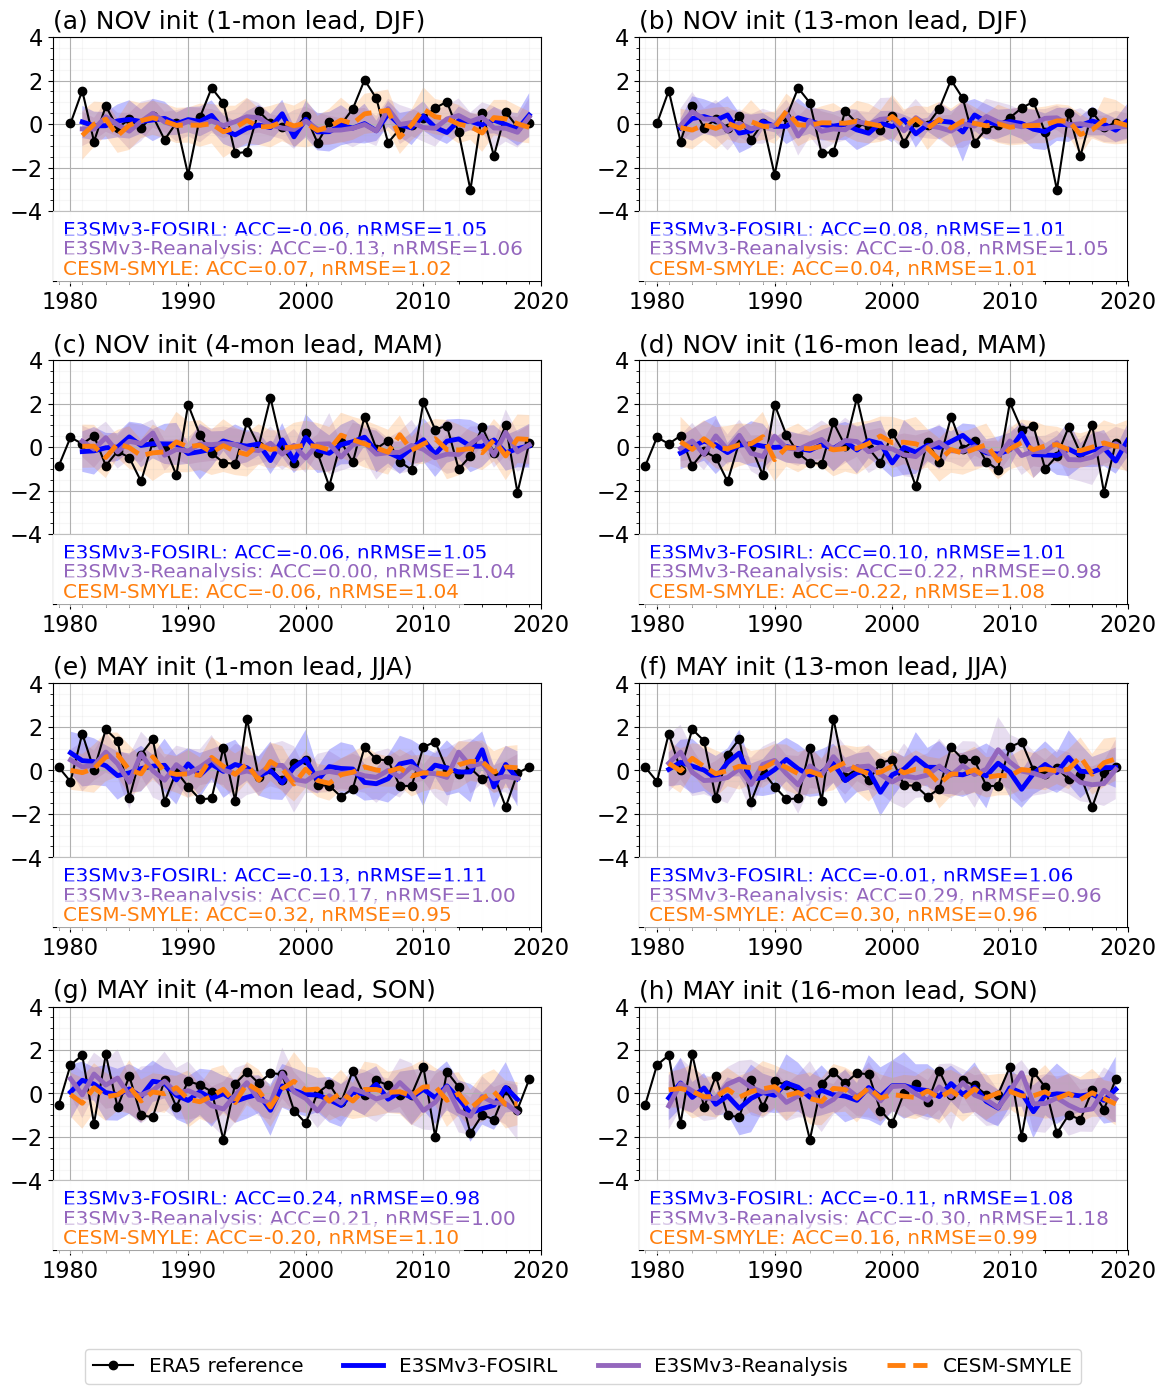

In [ ]:
# -----------------------------
# Plot projected EOF PC time series
# -----------------------------
# This mirrors the DJF Niño3.4 time-series layout: observations in black,
# model mean/spread and benchmarks configured in FIGURE_SETUP["pc_time_series"].
pc_method = "eof"
pc_startmonths_requested = [11, 5]
pc_leads = {
    11: [3, 15],   # NOV init: first- and second-year DJF targets
    5: [9, 21],    # MAY init: first- and second-year DJF targets
}

pc_settings = FIGURE_SETUP["pc_time_series"]

# Dynamically determine which requested initialization months are available across models
pc_startmonths_plot = []
for month in pc_startmonths_requested:
    if month in init_months:
        available = False
        for model in models:
            if (
                model in model_index
                and pc_method in model_index[model]
                and month in model_index[model][pc_method]
            ):
                available = True
                break
        if available:
            pc_startmonths_plot.append(month)

if not pc_startmonths_plot:
    raise ValueError("No requested initialization months are available for PC plotting.")

pc_nrow = len(pc_startmonths_plot)
pc_ncol = 2

pc_fontz = fontz
pc_scales = pc_settings.get("fontsize_scales", {})
pc_title_fontz = pc_fontz * pc_scales.get("title", 1.05)
pc_tick_fontz = pc_fontz * pc_scales.get("tick", 0.9)
pc_legend_fontz = pc_fontz * pc_scales.get("legend", 0.9)
pc_annotation_fontz = pc_fontz * pc_scales.get("annotation", 0.9)

pc_fig_width = pc_settings.get("figsize_width", 14)
pc_row_height = pc_fig_width * pc_settings.get("figsize_row_height_factor", 0.6) / pc_ncol
pc_line_width = pc_settings.get("line_width", 3.5)
pc_obs_marker_size = pc_settings.get("obs_marker_size", 6)
pc_grid_minor_alpha = pc_settings.get("grid_minor_alpha", 0.3)
pc_annotation_box = pc_settings.get("annotation_box", dict(facecolor="white", alpha=0.75, edgecolor="none"))

pc_data_ylim = pc_settings.get("plot_ylim", [-4.0, 4.0])
pc_annotation_band_height = pc_settings.get("annotation_band_height", 0.0)
pc_plot_ylim = [pc_data_ylim[0] - pc_annotation_band_height, pc_data_ylim[1]]
pc_major_yticks = pc_settings.get("major_yticks", [-4, -2, 0, 2, 4])
minor_step = pc_settings.get("minor_yticks_step", 0.5)
pc_minor_yticks = np.arange(pc_data_ylim[0] + minor_step, pc_data_ylim[1], minor_step)

pc_plot_xmin = verification_year0 - 0.5
pc_plot_xmax = verification_year1 + 1.0
pc_major_year_step = pc_settings.get("major_year_step", 10)
pc_minor_year_step = pc_settings.get("minor_year_step", 2)
pc_major_years = np.arange(
    int(np.ceil(verification_year0 / pc_major_year_step) * pc_major_year_step),
    verification_year1 + pc_major_year_step,
    pc_major_year_step,
)
pc_minor_years = np.arange(verification_year0, verification_year1 + 1, pc_minor_year_step)

pc_hindcast_label = pc_settings.get("hindcast_label", {11: "NOV", 5: "MAY"})
pc_hindcast_color = pc_settings.get("hindcast_color", {11: "g", 5: "b"})
pc_obs_color = pc_settings.get("obs_color", "k")
pc_target_season_labels = pc_settings.get("target_season_labels", {1: "DJF", 4: "MAM", 7: "JJA", 10: "SON"})

plt.rcParams.update({
    "font.size": pc_fontz,
    "axes.titlesize": pc_title_fontz,
    "xtick.labelsize": pc_tick_fontz,
    "ytick.labelsize": pc_tick_fontz,
    "legend.fontsize": pc_legend_fontz,
})


def _time_part_values(time_da, part, drop_missing=False):
    values = np.asarray(time_da.values).ravel()
    out = []

    for t in values:
        value = np.nan
        try:
            if t is not None:
                if hasattr(t, part):
                    value = getattr(t, part)
                else:
                    ts = pd.Timestamp(t)
                    if not pd.isna(ts):
                        value = getattr(ts, part)
        except (TypeError, ValueError, OverflowError):
            value = np.nan

        out.append(value)

    arr = np.asarray(out, dtype=float)
    if drop_missing:
        arr = arr[np.isfinite(arr)]
    return arr


def _year_values(time_da):
    return _time_part_values(time_da, "year")


def _month_values(time_da):
    return _time_part_values(time_da, "month")


def _member_dim(data_array):
    for candidate in ("M", "member", "ensemble"):
        if candidate in data_array.dims:
            return candidate
    return None


def _obs_pc_for_target_month(obs_da, target_month):
    if "time" not in obs_da.dims:
        raise ValueError("Observed PC series must include a time dimension.")

    month_values = _month_values(obs_da["time"])
    valid = np.isfinite(month_values)
    valid[valid] = month_values[valid].astype(int) == int(target_month)
    obs_series = obs_da.isel(time=valid)
    obs_years = _year_values(obs_series["time"])
    obs_valid_years = np.isfinite(obs_years)
    obs_series = obs_series.isel(time=obs_valid_years)
    obs_years = obs_years[obs_valid_years].astype(int)
    return obs_series.assign_coords(time=("time", obs_years))


def _plot_model_pc_panel(
    ax,
    model,
    init_month,
    lead,
    target_month,
    color,
    linestyle,
    label,
    spread_alpha,
    annotation_xy,
):
    data = model_index[model][pc_method][init_month].sel(L=lead)
    valid_time = model_time[model][init_month].sel(L=lead)
    years = _year_values(valid_time)
    valid = np.isfinite(years)
    years = years[valid]
    data = data.isel(Y=valid)

    months = _month_values(valid_time.isel(Y=valid))
    months = months[np.isfinite(months)]
    if months.size and not np.all(months.astype(int) == int(target_month)):
        raise ValueError(
            f"Expected target month {target_month} for {model} init={init_month}, "
            f"L={lead}; found months {np.unique(months.astype(int))}"
        )

    member_dim = _member_dim(data)
    if member_dim is not None:
        data_mean = data.mean(member_dim)
        data_std = data.std(member_dim)
    else:
        data_mean = data
        data_std = xr.zeros_like(data)

    ax.plot(
        years,
        data_mean,
        color=color,
        linewidth=pc_line_width,
        linestyle=linestyle,
        label=label,
    )
    ax.fill_between(
        years,
        (data_mean - data_std).values,
        (data_mean + data_std).values,
        fc=color,
        alpha=spread_alpha,
    )

    if lead in skill[model][pc_method][init_month].L.values:
        skill_row = skill[model][pc_method][init_month].sel(L=lead)
        if annotation_xy is not None:
            txt = ax.text(
                *annotation_xy,
                f"{label}: ACC={float(skill_row.corr):3.2f}, nRMSE={float(skill_row.rmse):3.2f}",
                transform=ax.transAxes,
                fontsize=pc_annotation_fontz,
                color=color,
                bbox=pc_annotation_box,
                zorder=8,
            )
            txt.set_in_layout(False)


# Select the 8 cases consistent with EOF patterns:
pattern_years = FIGURE_SETUP["eof_patterns"].get("pattern_years", (1, 2))
pattern_seasons = FIGURE_SETUP["eof_patterns"].get("pattern_seasons", ("DJF", "MAM", "JJA", "SON"))
preferred_init_by_season = FIGURE_SETUP["eof_patterns"].get("preferred_init_by_season", {
    "DJF": 11,
    "MAM": 11,
    "JJA": 5,
    "SON": 5,
})

# Let's gather all available (init_month, lead, target_year, target_season, target_month)
available_cases = []
for init_month in pc_startmonths_plot:
    ref_model = None
    for m in models:
        if m in model_index and pc_method in model_index[m] and init_month in model_index[m][pc_method]:
            ref_model = m
            break
    if ref_model is None:
        continue
    
    ref_ds = model_index[ref_model][pc_method][init_month]
    for lead_val in ref_ds.L.values:
        lead = int(lead_val)
        display_lead = lead - 2
        
        target_month = int(model_time[ref_model][init_month].sel(L=lead).dt.month.values[0])
        target_season = pc_target_season_labels.get(target_month, f"month {target_month:02d}")
        target_year = mov.target_year_from_display_lead(display_lead)
        
        available_cases.append({
            "init_month": init_month,
            "lead": lead,
            "display_lead": display_lead,
            "target_year": target_year,
            "target_month": target_month,
            "target_season": target_season,
        })

# 4 rows and 2 columns: column is year, row is season
pc_cases = []
for target_season in pattern_seasons:
    for target_year in pattern_years:
        candidates = [
            c for c in available_cases
            if c["target_year"] == target_year and c["target_season"] == target_season
        ]
        if not candidates:
            continue
        preferred_init = preferred_init_by_season.get(target_season)
        candidates = sorted(
            candidates,
            key=lambda c: (
                c["init_month"] != preferred_init,
                c["display_lead"],
                c["init_month"],
            )
        )
        pc_cases.append(candidates[0])

if not pc_cases:
    raise ValueError("No PC time series cases were selected.")

pc_nrow = 4
pc_ncol = 2
pc_row_height = 3.6
pc_fig_width = pc_settings.get("figsize_width", 14)
fig = plt.figure(figsize=(pc_fig_width, pc_row_height * pc_nrow))
pc_panel_index = 0

for idx, case in enumerate(pc_cases):
    init_month = case["init_month"]
    lead = case["lead"]
    display_lead = case["display_lead"]
    target_month = case["target_month"]
    target_season = case["target_season"]
    target_year = case["target_year"]
    
    ax = fig.add_subplot(pc_nrow, pc_ncol, idx + 1)
    pc_panel_index += 1
    panel_label = f"({chr(ord('a') + pc_panel_index - 1)})"

    ax.set_ylim(pc_plot_ylim)
    ax.set_yticks(pc_major_yticks)
    ax.set_yticks(pc_minor_yticks, minor=True)
    ax.set_xlim([pc_plot_xmin, pc_plot_xmax])
    ax.set_xticks(pc_major_years)
    ax.set_xticks(pc_minor_years, minor=True)
    ax.tick_params(axis="both", labelsize=pc_tick_fontz)
    ax.grid(True, which="major")
    ax.grid(True, which="minor", alpha=pc_grid_minor_alpha)

    # Title
    title = (
        f"{panel_label} {pc_hindcast_label.get(init_month, init_month)} init "
        f"({display_lead}-mon lead, {target_season})"
    )
    ax.set_title(title, loc="left", fontsize=pc_title_fontz)

    obs_pc = _obs_pc_for_target_month(obs_index[pc_method], target_month)
    ax.plot(
        obs_pc.time,
        obs_pc,
        color=pc_obs_color,
        marker=".",
        markersize=pc_obs_marker_size,
        label=f"{reference_product} reference",
    )

    # Plot all models dynamically based on custom styles
    for model in models:
        if (
            model in model_index
            and pc_method in model_index[model]
            and init_month in model_index[model][pc_method]
            and lead in model_index[model][pc_method][init_month].L.values
        ):
            m_style = pc_settings["model_styles"].get(model, {})
            label = m_style.get("label", model)
            linestyle = m_style.get("linestyle", "-")
            spread_alpha = m_style.get("spread_alpha", 0.15)
            annotation_xy = m_style.get("annotation_xy", None)

            color_cfg = m_style.get("colors")
            if isinstance(color_cfg, dict):
                color = color_cfg.get(init_month, "tab:blue")
            elif isinstance(color_cfg, str):
                color = color_cfg
            else:
                color = pc_hindcast_color.get(init_month, "tab:blue")

            _plot_model_pc_panel(
                ax,
                model,
                init_month,
                lead,
                target_month,
                color,
                linestyle,
                label,
                spread_alpha,
                annotation_xy,
            )

    if pc_annotation_band_height > 0:
        ax.axhspan(
            pc_plot_ylim[0],
            pc_data_ylim[0],
            facecolor=pc_settings.get("annotation_band_facecolor", "white"),
            alpha=pc_settings.get("annotation_band_alpha", 0.96),
            edgecolor="none",
            zorder=6,
        )
        ax.axhline(
            pc_data_ylim[0],
            color=pc_settings.get("annotation_band_edgecolor", "0.75"),
            linewidth=0.8,
            zorder=7,
        )

fig.tight_layout()
fig.subplots_adjust(bottom=pc_settings.get("subplots_adjust_bottom", 0.12))

# Global legend at the bottom of the figure on a single line with a frame box
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles=handles,
    labels=labels,
    loc=pc_settings.get("legend_loc", "lower center"),
    ncol=pc_settings.get("legend_ncol", 3),
    bbox_to_anchor=pc_settings.get("legend_bbox_to_anchor", (0.5, 0.02)),
    fontsize=pc_legend_fontz,
    frameon=pc_settings.get("legend_frameon", True),
)
figpath = FIGURE_OUTDIR / mov.figure_filename(selected_mode, "pc_time_series")
mov.save_figure(
    fig,
    figpath,
    mode=selected_mode,
    metric="pc_time_series",
    title=f"{selected_mode} Projected EOF PC Time Series",
    caption=(
        f"Projected EOF PC time series, {verification_year0}-{verification_year1} verification, "
        f"{climy0}-{climy1} anomaly baseline, {reference_product} reference"
    ),
    dpi=figure_dpi,
    reference=reference_product,
)
print(figpath)
plt.show()


## Export Compact Numeric Backup


In [ ]:
summary_rows = []
for model in models:
    for method in analysis_methods:
        for init_month in init_months:
            dataset = skill[model][method][init_month]
            for lead in dataset.L.values:
                summary_rows.append(
                    {
                        "mode": selected_mode,
                        "model": model,
                        "method": method,
                        "init_month": init_month,
                        "lead": int(lead),
                        "verification_start_year": verification_year0,
                        "verification_end_year": verification_year1,
                        "anomaly_climatology_start_year": climy0,
                        "anomaly_climatology_end_year": climy1,
                        "eof_reference_start_year": eof_reference_year0,
                        "eof_reference_end_year": eof_reference_year1,
                        "acc": float(dataset["corr"].sel(L=lead)),
                        "pval": float(dataset["pval"].sel(L=lead)),
                        "nrmse": float(dataset["rmse"].sel(L=lead)),
                    }
                )

summary_df = pd.DataFrame(summary_rows)
summary_df[f"significant_p_lt_{significance_level:g}"] = (
    summary_df["pval"] < significance_level
)

if write_summary_tables:
    table_outdir.mkdir(parents=True, exist_ok=True)
    stem = (
        f"{selected_mode.lower()}_multimodel_skill_verify{verification_year0}_{verification_year1}_clim{climy0}_{climy1}"
    )
    csv_path = table_outdir / f"{stem}.csv"
    txt_path = table_outdir / f"{stem}.txt"
    summary_df.to_csv(csv_path, index=False, float_format="%.4f")
    txt_path.write_text(
        summary_df.to_string(
            index=False, float_format=lambda value: f"{value:.4f}"
        )
    )
    print(csv_path)
    print(txt_path)

summary_df.head(12)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/modes_variability/tables/ea_multimodel_skill_verify1979_2019_clim1981_2010.csv
/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/modes_variability/tables/ea_multimodel_skill_verify1979_2019_clim1981_2010.txt


,mode,model,method,init_month,lead,verification_start_year,verification_end_year,anomaly_climatology_start_year,anomaly_climatology_end_year,eof_reference_start_year,eof_reference_end_year,acc,pval,nrmse,significant_p_lt_0.1
0,EA,E3SM-FOSIRL,eof,5,3,1979,2019,1981,2010,1979,2019,-0.131824,0.436724,1.110921,False
1,EA,E3SM-FOSIRL,eof,5,6,1979,2019,1981,2010,1979,2019,0.236270,0.147590,0.976192,False
2,EA,E3SM-FOSIRL,eof,5,9,1979,2019,1981,2010,1979,2019,-0.240070,0.146562,1.069894,False
3,EA,E3SM-FOSIRL,eof,5,12,1979,2019,1981,2010,1979,2019,0.138213,0.421465,1.002544,False
4,EA,E3SM-FOSIRL,eof,5,15,1979,2019,1981,2010,1979,2019,-0.008390,0.959572,1.064591,False
5,EA,E3SM-FOSIRL,eof,5,18,1979,2019,1981,2010,1979,2019,-0.112578,0.500987,1.084241,False
6,EA,E3SM-FOSIRL,eof,5,21,1979,2019,1981,2010,1979,2019,-0.052050,0.756295,1.047397,False
7,EA,E3SM-FOSIRL,eof,11,3,1979,2019,1981,2010,1979,2019,-0.060919,0.716365,1.049091,False
8,EA,E3SM-FOSIRL,eof,11,6,1979,2019,1981,2010,1979,2019,-0.060489,0.726002,1.054886,False
9,EA,E3SM-FOSIRL,eof,11,9,1979,2019,1981,2010,1979,2019,-0.286060,0.081670,1.171928,True


## PCMDI EOF Pattern Diagnostics


EOF map pattern variable: mode_pattern (regional EOF-domain maps)
Using atlantic map projection for EA panels.
Missing significance diagnostics: ['ERA5 DJF', 'ERA5 MAM', 'ERA5 JJA', 'ERA5 SON', 'ERA5 DJF', 'ERA5 MAM', 'ERA5 JJA', 'ERA5 SON']
/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_ea_eof_patterns.png


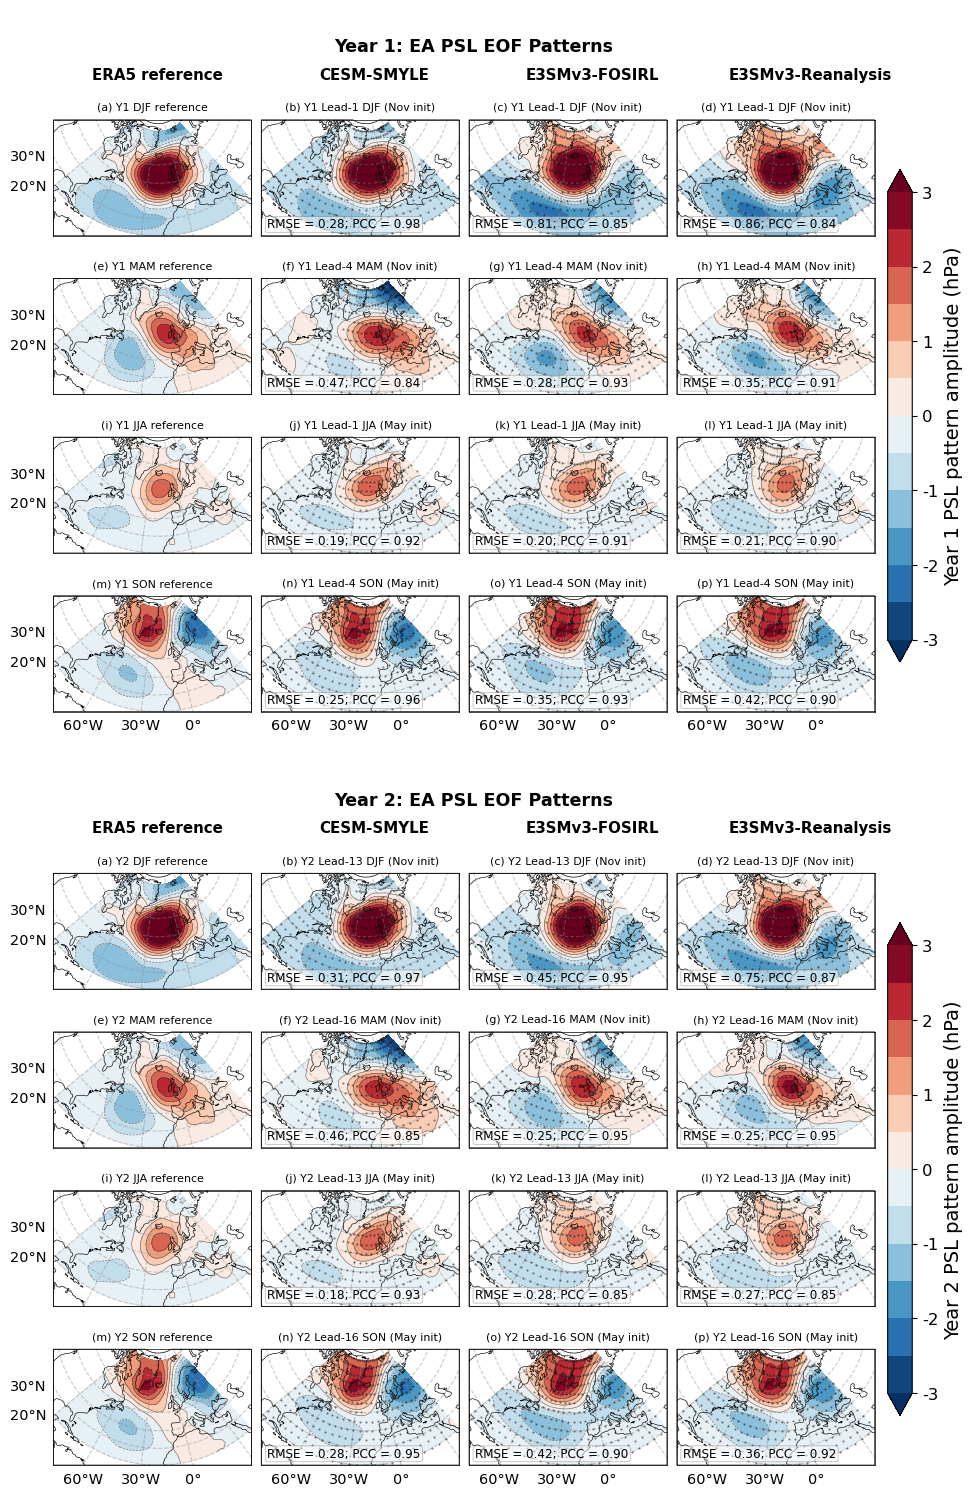

In [ ]:
eof_plot = FIGURE_SETUP["eof_patterns"]

# ---------------------------------------------------------------------
# Derived font sizes for EOF-pattern figure
# ---------------------------------------------------------------------
year_section_title_fontsize = fontz * eof_plot.get("year_section_title_scale", 0.90)
column_header_fontsize = fontz * eof_plot.get("column_header_scale", 0.85)
panel_title_fontsize = fontz * eof_plot.get("panel_title_scale", 0.60)
metric_box_fontsize = fontz * eof_plot.get("metric_box_font_scale", 0.62)
map_label_fontsize = fontz * eof_plot.get("map_label_scale", 0.45)
axis_label_fontsize = fontz * eof_plot.get("axis_label_scale", 0.90)
tick_label_fontsize = fontz * eof_plot.get("tick_label_scale", 0.58)
colorbar_label_fontsize = fontz * eof_plot.get("colorbar_label_scale", 0.78)
colorbar_tick_fontsize = fontz * eof_plot.get("colorbar_tick_scale", 0.66)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
target_seasons = {1: "DJF", 4: "MAM", 7: "JJA", 10: "SON"}
pattern_model_order = tuple(
    model
    for model in ("SMYLE", "E3SM-FOSIRL", "E3SM-Reanalysis", "NMME")
    if model in models
)
column_titles = [f"{reference_product} reference"] + [
    model_display_names[model] for model in pattern_model_order
]

reference_pattern_variable = "mode_pattern"
reference_mask_variable = "mode_ocean_mask"
print("EOF map pattern variable:", reference_pattern_variable, "(regional EOF-domain maps)")


def model_pattern_variable(dataset):
    return "mode_pattern"


def pattern_significance_for_plot(dataset, selector, *, is_reference=False):
    return mov.pattern_significance(
        dataset,
        selector,
        allow_regression=not is_reference,
        eof_bootstrap_confidence=eof_bootstrap_confidence,
    )


def build_pattern_cases():
    available = []

    for init_month in init_months:
        reference_dataset = model_datasets[pattern_model_order[0]][init_month]

        for lead_value in reference_dataset["mode_pattern"].L.values:
            lead = int(lead_value)
            display_lead = lead - 2

            target_months = {
                model: int(
                    model_datasets[model][init_month]["target_month"].sel(L=lead)
                )
                for model in pattern_model_order
                if lead in set(map(
                    int, model_datasets[model][init_month]["mode_pattern"].L.values
                ))
            }

            if len(set(target_months.values())) != 1:
                raise ValueError(
                    f"Target-month mismatch for init {init_month:02d}, "
                    f"lead {lead}: {target_months}"
                )

            target_month = next(iter(target_months.values()))
            target_season = target_seasons.get(target_month, month_names[target_month])

            available.append(
                {
                    "init_month": init_month,
                    "lead": lead,
                    "display_lead": display_lead,
                    "target_year": mov.target_year_from_display_lead(display_lead),
                    "target_month": target_month,
                    "target_season": target_season,
                }
            )

    selected = []

    for target_year in eof_plot["pattern_years"]:
        for target_season in eof_plot["pattern_seasons"]:
            candidates = [
                case
                for case in available
                if case["target_year"] == target_year
                and case["target_season"] == target_season
            ]

            if not candidates:
                print(f"No pattern panel available for year {target_year} {target_season}.")
                continue

            preferred_init = eof_plot["preferred_init_by_season"].get(target_season)

            candidates = sorted(
                candidates,
                key=lambda case: (
                    case["init_month"] != preferred_init,
                    case["display_lead"],
                    case["init_month"],
                ),
            )

            selected.append(candidates[0])

    return selected


pattern_rows = []
missing_significance_panels = []
significance_sources = set()

pattern_cases = build_pattern_cases()
if not pattern_cases:
    raise ValueError("No pattern panels were selected.")

for case in pattern_cases:
    init_month = case["init_month"]
    lead = case["lead"]
    display_lead = case["display_lead"]
    target_month = case["target_month"]
    target_season = case["target_season"]
    target_year = case["target_year"]

    reference_pattern = obs_dataset[reference_pattern_variable].sel(
        target_month=target_month
    )
    plot_ocean_mask = None
    if reference_mask_variable in obs_dataset:
        plot_ocean_mask = (
            obs_dataset[reference_mask_variable]
            .sel(target_month=target_month)
            .astype(bool)
        )
        reference_pattern = mov.mask_pattern_for_plot(
            reference_pattern, plot_ocean_mask
        )

    reference_significant, significance_label = pattern_significance_for_plot(
        obs_dataset,
        {"target_month": target_month},
        is_reference=True,
    )

    if significance_label:
        significance_sources.add(significance_label)

    if reference_significant is None:
        missing_significance_panels.append(f"{reference_product} {target_season}")
    elif plot_ocean_mask is not None:
        reference_significant = (
            reference_significant.astype(bool) & plot_ocean_mask
        ).astype(bool)

    panels = [
        (
            reference_pattern,
            f"Y{target_year} {target_season} reference",
            None,
            reference_significant,
        )
    ]

    for model in pattern_model_order:
        dataset = model_datasets[model][init_month]
        model_leads = set(map(int, dataset[model_pattern_variable(dataset)].L.values))
        if lead not in model_leads:
            panels.append((None, f"{model} lead not available", None, None))
            continue
        model_pattern = dataset[model_pattern_variable(dataset)].sel(L=lead)
        model_pattern = mov.mask_pattern_for_plot(model_pattern, plot_ocean_mask)

        model_significant, significance_label = pattern_significance_for_plot(
            dataset,
            {"L": lead},
            is_reference=False,
        )

        if significance_label:
            significance_sources.add(significance_label)

        if model_significant is None:
            missing_significance_panels.append(
                f"{model} init {init_month:02d} lead {display_lead}"
            )
        elif plot_ocean_mask is not None:
            model_significant = (
                model_significant.astype(bool) & plot_ocean_mask
            ).astype(bool)

        rmse, pcc = mov.spatial_pattern_metrics(model_pattern, reference_pattern)

        if {
            "mode_pattern_rmse_reference",
            "mode_pattern_pcc_reference",
        } <= set(dataset.data_vars):
            stored_rmse = float(dataset["mode_pattern_rmse_reference"].sel(L=lead))
            stored_pcc = float(dataset["mode_pattern_pcc_reference"].sel(L=lead))

            np.testing.assert_allclose(rmse, stored_rmse, rtol=1e-6, atol=1e-8)
            np.testing.assert_allclose(pcc, stored_pcc, rtol=1e-6, atol=1e-8)

        panels.append(
            (
                model_pattern,
                (
                    f"Y{target_year} Lead-{display_lead} {target_season} "
                    f"({month_names[init_month]} init)"
                ),
                (
                    f"RMSE = {rmse:.{eof_plot['rmse_decimals']}f}; "
                    f"PCC = {pcc:.{eof_plot['pcc_decimals']}f}"
                ),
                model_significant,
            )
        )

    pattern_rows.append(panels)


levels = np.asarray(eof_plot["levels"], dtype=float)
if levels.ndim != 1 or levels.size < 2 or not np.all(np.diff(levels) > 0):
    raise ValueError(
        "FIGURE_SETUP['eof_patterns']['levels'] must be a strictly "
        "increasing 1D sequence."
    )

reference_pattern = pattern_rows[0][0][0]
map_projection, map_projection_name = mov.make_projection(
    selected_mode,
    albers_projection_by_mode=ALBERS_PROJECTION_BY_MODE,
    use_cartopy=eof_plot.get("use_cartopy", True),
)
data_crs = mov.data_crs() if map_projection is not None else None
map_extent = mov.mode_extent(selected_mode, reference_pattern)

lon_limits = (
    float(reference_pattern.lon.min()),
    float(reference_pattern.lon.max()),
)
lon_ticks = np.linspace(lon_limits[0], lon_limits[1], 5)

subplot_kw = {"projection": map_projection} if map_projection is not None else {}

if map_projection is None and mov.CARTOPY_IMPORT_ERROR is not None:
    print(
        "Cartopy unavailable; using plain latitude-longitude axes:",
        mov.CARTOPY_IMPORT_ERROR,
    )
elif map_projection_name is not None:
    print(f"Using {map_projection_name} map projection for {selected_mode} panels.")


display_row_by_pattern_row = {}
header_display_row_by_year = {}
height_ratios = [eof_plot["top_section_gap_ratio"]]

display_row = 1
previous_year = None

for row in range(len(pattern_rows)):
    target_year = pattern_cases[row]["target_year"]

    if target_year != previous_year:
        if previous_year is not None:
            height_ratios.append(eof_plot["year_section_gap_ratio"])
            display_row += 1

        header_display_row_by_year[target_year] = display_row
        height_ratios.append(eof_plot["year_section_header_ratio"])
        display_row += 1
        previous_year = target_year

    display_row_by_pattern_row[row] = display_row
    height_ratios.append(1.0)
    display_row += 1

plot_display_rows = set(display_row_by_pattern_row.values())
display_nrows = len(height_ratios)

# Polar panels need extra horizontal space for outside longitude labels and
# a dedicated colorbar gutter. Scale those layout values with the number of
# columns so adding another model/reference column does not require retuning.
ncols = len(column_titles)
if map_projection_name in {"north_polar", "south_polar"}:
    polar_column_width = eof_plot.get("polar_column_width", 4.45)
    polar_colorbar_width = eof_plot.get("polar_colorbar_width", 1.45)
    eof_plot["figsize_width"] = max(
        eof_plot.get("figsize_width", 0),
        polar_column_width * ncols + polar_colorbar_width,
    )
    eof_plot["subplot_right"] = eof_plot.get(
        "polar_subplot_right_by_ncol",
        {3: 0.845, 4: 0.815, 5: 0.790},
    ).get(ncols, max(0.72, 0.88 - 0.025 * ncols))
    eof_plot["subplot_wspace"] = eof_plot.get(
        "polar_subplot_wspace_by_ncol",
        {3: 0.28, 4: 0.36, 5: 0.42},
    ).get(ncols, min(0.48, 0.18 + 0.05 * ncols))
    eof_plot["colorbar_pad"] = eof_plot.get("polar_colorbar_pad", 0.080)
    eof_plot["colorbar_fraction"] = eof_plot.get("polar_colorbar_fraction", 0.026)

fig, axes = plt.subplots(
    display_nrows,
    ncols,
    figsize=(
        eof_plot["figsize_width"],
        eof_plot["figsize_row_height"] * sum(height_ratios),
    ),
    constrained_layout=False,
    sharex=True,
    sharey=True,
    squeeze=False,
    subplot_kw=subplot_kw,
    gridspec_kw={"height_ratios": height_ratios},
)

fig.subplots_adjust(
    left=eof_plot.get("subplot_left", 0.045),
    right=eof_plot.get("subplot_right", 0.915),
    bottom=eof_plot.get("subplot_bottom", 0.035),
    top=eof_plot.get("subplot_top", 0.975),
    wspace=eof_plot.get("subplot_wspace", 0.08),
    hspace=eof_plot.get("subplot_hspace", 0.20),
)

for display_row in range(display_nrows):
    if display_row in plot_display_rows:
        continue
    for col in range(ncols):
        axes[display_row, col].set_axis_off()

plot_axes = axes[list(display_row_by_pattern_row.values()), :]

# ---------------------------------------------------------------------
# Compute column centers from actual plotted map axes.
# This gives better alignment than using hidden header axes.
# ---------------------------------------------------------------------
#column_centers = [
#    (plot_axes[0, col].get_position().x0 +
#     plot_axes[0, col].get_position().x1) / 2
#    for col in range(plot_axes.shape[1])
#]
column_centers = []
column_header_shift_by_col = eof_plot.get("column_header_shift_by_col", {})
for col in range(plot_axes.shape[1]):
    x0 = min(ax.get_position().x0 for ax in plot_axes[:, col])
    x1 = max(ax.get_position().x1 for ax in plot_axes[:, col])
    center = (x0 + x1) / 2
    center += eof_plot.get("column_header_shift_per_col", 0.0) * col
    center += column_header_shift_by_col.get(col, 0.0)
    column_centers.append(center)

header_axes = {
    target_year: axes[display_row, :]
    for target_year, display_row in header_display_row_by_year.items()
}

section_last_rows = {
    max(
        row
        for row, case in enumerate(pattern_cases)
        if case["target_year"] == target_year
    )
    for target_year in eof_plot["pattern_years"]
    if any(case["target_year"] == target_year for case in pattern_cases)
}


# ---------------------------------------------------------------------
# Year-section titles and column headers
# ---------------------------------------------------------------------
for target_year in eof_plot["pattern_years"]:
    rows = [
        row
        for row, case in enumerate(pattern_cases)
        if case["target_year"] == target_year
    ]

    if not rows:
        continue

    section_season_label = "/".join(
        pattern_cases[row]["target_season"] for row in rows
    )

    header_pos = header_axes[target_year][1].get_position()
    header_center_y = header_pos.y0 + 0.50 * header_pos.height

    year_title_y = header_pos.y0 + eof_plot.get("year_title_y_ratio", 0.72) * header_pos.height
    column_title_y = header_pos.y0 + eof_plot.get("column_title_y_ratio", 0.25) * header_pos.height

    fig.text(
        0.5,
        year_title_y,
        f"Year {target_year}: {selected_mode} {source_field} EOF Patterns",
        ha="center",
        va="center",
        fontsize=year_section_title_fontsize,
        fontweight="bold",
    )

    for col, column_title in enumerate(column_titles):
        col_x = column_centers[col]
        col_y = column_title_y
        col_x_shift = eof_plot.get("column_header_x_shift_by_col", {}).get(col, 0.0)
        col_y_shift = eof_plot.get("column_header_y_shift_by_col", {}).get(col, 0.0)
        col_x = eof_plot.get("column_header_x_by_col", {}).get(col, col_x + col_x_shift)
        col_y = eof_plot.get("column_header_y_by_col", {}).get(col, col_y + col_y_shift)
        fig.text(
            col_x,
            col_y,
            column_title,
            ha="center",
            va="center",
            fontsize=column_header_fontsize,
            fontweight="bold",
        )


images_by_year = {}
# Build row number within each year section
year_row_index = {}
for target_year in eof_plot["pattern_years"]:
    rows_in_year = [
        r
        for r, case in enumerate(pattern_cases)
        if case["target_year"] == target_year
    ]
    for local_row, global_row in enumerate(rows_in_year):
        year_row_index[global_row] = local_row

# Plot panels and collect images for shared colorbars
for row, panels in enumerate(pattern_rows):
    row_year = pattern_cases[row]["target_year"]

    for col, (pattern, title, metrics_text, significant) in enumerate(panels):
        local_row = year_row_index[row]
        panel_label = chr(
            ord("a") + local_row * ncols + col
        )
        ax = plot_axes[row, col]
        if pattern is None:
            ax.set_axis_off()
            ax.set_title(
                f"({panel_label}) {title}",
                loc=eof_plot.get("panel_title_loc", "left"),
                fontsize=panel_title_fontsize,
                pad=eof_plot.get("panel_title_pad", 3),
            )
            continue
        plot_pattern = mov.add_cyclic_longitude_for_plot(pattern)

        if map_projection is not None:
            mov.apply_polar_circular_boundary(
                plot_axes[row, col],
                map_projection_name,
                enabled=eof_plot.get("polar_circular_boundary", True),
            )

        image = plot_axes[row, col].contourf(
            plot_pattern.lon,
            plot_pattern.lat,
            plot_pattern,
            levels=levels,
            cmap="RdBu_r",
            extend="both",
            transform=data_crs,
        )

        if eof_plot["draw_contour_lines"]:
            plot_axes[row, col].contour(
                plot_pattern.lon,
                plot_pattern.lat,
                plot_pattern,
                levels=eof_plot["contour_line_levels"],
                colors=eof_plot["contour_line_color"],
                linewidths=eof_plot["contour_linewidth"],
                alpha=eof_plot["contour_line_alpha"],
                transform=data_crs,
            )

        images_by_year[row_year] = image

        if significant is not None:
            plot_significant = mov.add_cyclic_longitude_for_plot(significant)
            stipple = plot_significant.isel(
                lat=slice(None, None, eof_plot["stipple_stride"]),
                lon=slice(None, None, eof_plot["stipple_stride"]),
            )
            stipple_lon, stipple_lat = np.meshgrid(stipple.lon, stipple.lat)

            plot_axes[row, col].scatter(
                stipple_lon[stipple.values],
                stipple_lat[stipple.values],
                s=eof_plot["stipple_size"],
                color=eof_plot["stipple_color"],
                alpha=eof_plot["stipple_alpha"],
                marker=".",
                linewidths=0,
                zorder=eof_plot["stipple_zorder"],
                transform=data_crs,
            )

        if map_projection is not None:
            mov.set_extent(
                plot_axes[row, col],
                map_projection_name,
                map_extent,
                data_crs,
            )
            mov.add_map_features(
                plot_axes[row, col],
                map_projection_name,
                eof_plot,
            )
            
            if map_projection_name in {"north_pacific", "atlantic"}:
                ax = plot_axes[row, col]

                # Remove rectangular GeoAxes frame/box
                ax.set_frame_on(True)

                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_linewidth(0.5)
            
            mov.configure_gridlines(
                plot_axes[row, col],
                mode=selected_mode,
                projection_name=map_projection_name,
                row=row,
                col=col,
                section_last_rows=section_last_rows,
                extent=map_extent,
                data_projection=data_crs,
                settings=eof_plot,
                fontsize=map_label_fontsize,
            )
        else:
            plot_axes[row, col].set_xlim(*lon_limits)
            plot_axes[row, col].set_xticks(lon_ticks)
        
        panel_title_x_by_col = eof_plot.get("panel_title_x_by_col", {})
        plot_axes[row, col].set_title(
            f"({panel_label}) {title}",
            loc="center",
            x=panel_title_x_by_col.get(col, eof_plot.get("panel_title_x", 0.5)),
            y=eof_plot.get("panel_title_y", 1.0),
            ha="center",
            fontsize=panel_title_fontsize,
            pad=eof_plot["panel_title_pad"],
            linespacing=eof_plot["panel_title_linespacing"],
        )

        if metrics_text is not None:
            is_polar_panel = map_projection_name in {"north_polar", "south_polar"}
            metric_x = eof_plot.get("polar_metric_box_x", 0.5) if is_polar_panel else eof_plot["metric_box_x"]
            metric_y = eof_plot.get("polar_metric_box_y", -0.135) if is_polar_panel else eof_plot["metric_box_y"]
            metric_ha = eof_plot.get("polar_metric_box_ha", "center") if is_polar_panel else "left"
            metric_va = eof_plot.get("polar_metric_box_va", "top") if is_polar_panel else "bottom"
            metric_text = metrics_text
            if is_polar_panel and eof_plot.get("polar_metric_two_lines", False):
                metric_text = metrics_text.replace("; ", "\n")
            plot_axes[row, col].text(
                metric_x,
                metric_y,
                metric_text,
                transform=plot_axes[row, col].transAxes,
                ha=metric_ha,
                va=metric_va,
                fontsize=metric_box_fontsize,
                zorder=eof_plot["metric_box_zorder"],
                clip_on=False,
                bbox={
                    "boxstyle": f"round,pad={eof_plot['metric_box_pad']}",
                    "facecolor": "white",
                    "edgecolor": "0.35",
                    "linewidth": eof_plot["metric_box_linewidth"],
                    "alpha": eof_plot["metric_box_alpha"],
                },
            )

        if row == len(pattern_rows) - 1:
            plot_axes[row, col].set_xlabel(
                "Longitude",
                fontsize=axis_label_fontsize,
            )

        plot_axes[row, col].tick_params(labelsize=tick_label_fontsize)

        if map_projection is None:
            plot_axes[row, col].grid(alpha=eof_plot["grid_alpha"])

        if col == 0 and map_projection is None:
            plot_axes[row, col].set_ylabel(
                "Latitude",
                fontsize=axis_label_fontsize,
            )


for target_year in eof_plot["pattern_years"]:
    rows = [
        row
        for row, case in enumerate(pattern_cases)
        if case["target_year"] == target_year
    ]

    if not rows:
        continue

    colorbar = fig.colorbar(
        images_by_year[target_year],
        ax=plot_axes[rows, :].ravel().tolist(),
        ticks=levels[::2],
        shrink=eof_plot["colorbar_shrink"],
        pad=eof_plot["colorbar_pad"],
        fraction=eof_plot["colorbar_fraction"],
    )
    colorbar.set_label(
        f"Year {target_year} {source_field} pattern amplitude ({field_units})",
        fontsize=colorbar_label_fontsize,
    )
    colorbar.ax.tick_params(labelsize=colorbar_tick_fontsize)
    colorbar.ax.set_yticklabels([f"{level:g}" for level in levels[::2]])


year_label = "-".join(f"Y{year}" for year in eof_plot["pattern_years"])
season_label = "/".join(eof_plot["pattern_seasons"])

if missing_significance_panels:
    print("Missing significance diagnostics:", missing_significance_panels)

figpath = FIGURE_OUTDIR / mov.figure_filename(selected_mode, "eof_patterns")

mov.save_figure(
    fig, figpath,
    mode=selected_mode,
    metric="eof_patterns",
    title=f"{selected_mode} EOF Patterns",
    caption=(
        f"{year_label} seasons: {season_label}, {reference_product} reference"
    ),
    dpi=figure_dpi,
    reference=reference_product,
)
print(figpath)
plt.show()


## Global Teleconnection Pattern Diagnostics


/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_ea_global_teleconnection_patterns.png


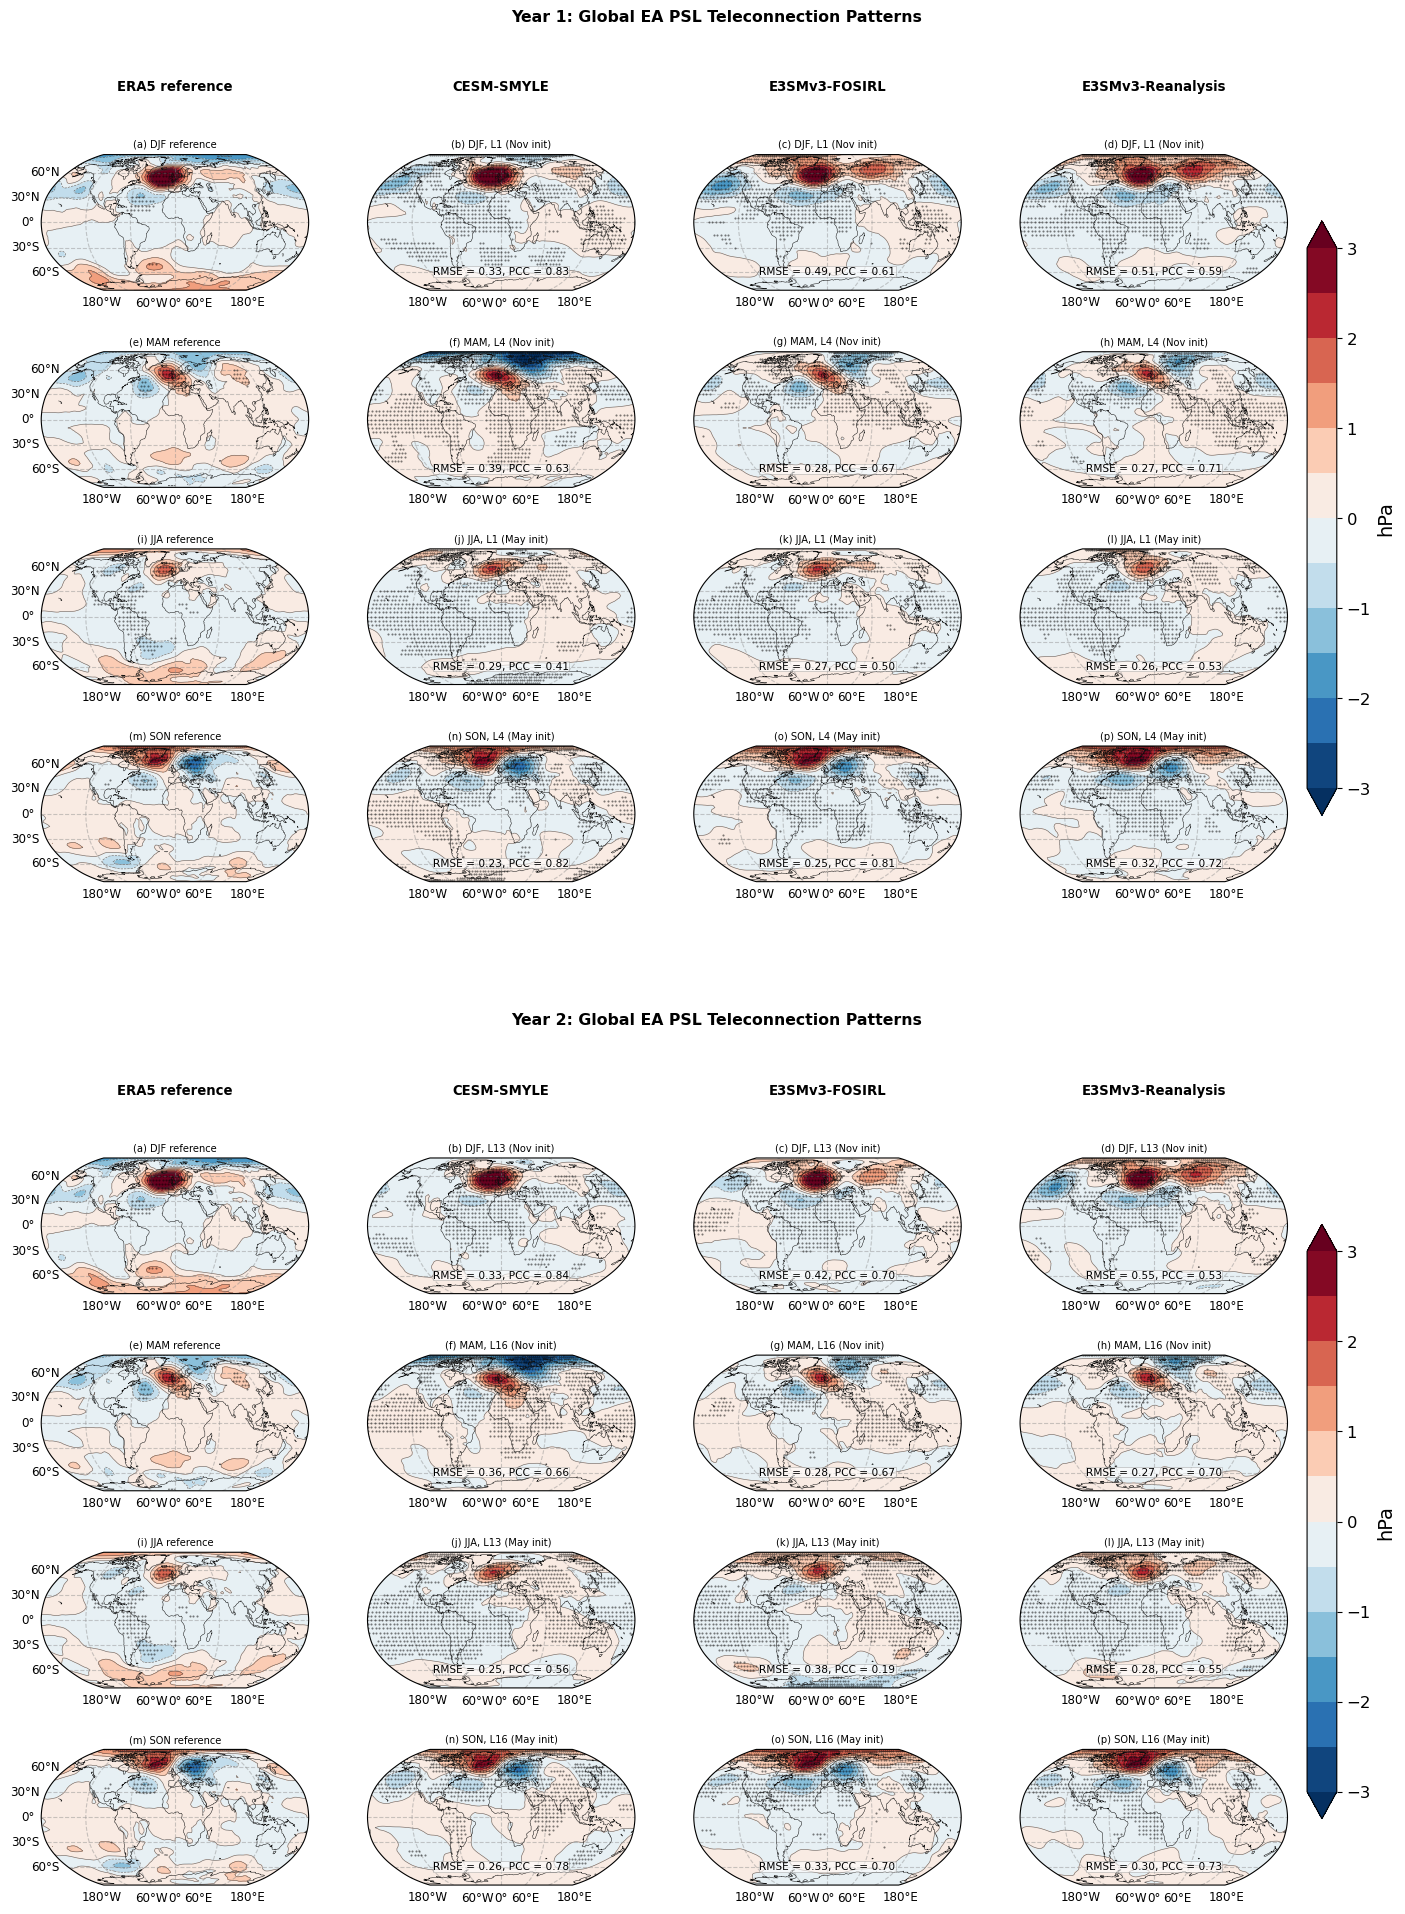

In [ ]:
# -----------------------------
# Plot global teleconnection regression patterns
# -----------------------------
teleconnection_variable = "mode_global_regression_pattern"
teleconnection_significance_variable = "mode_global_regression_significant"
def global_teleconnection_path(product, index_path):
    modes_root = modes_variability_root(index_path)
    return (
        modes_root / "regression_patterns"
        / f"{product.replace(':', '_')}_global_teleconnection.nc"
    )


reference_teleconnection_path = global_teleconnection_path(
    f"{selected_mode}:reference", obs_index_file
)
all_model_teleconnection_paths = {
    model: {
        init_month: global_teleconnection_path(
            f"{selected_mode}:{model_product_tags[model]}_init{init_month:02d}",
            model_index_files[model][init_month],
        )
        for init_month in init_months
    }
    for model in pattern_model_order
}
teleconnection_model_order = tuple(
    model
    for model in pattern_model_order
    if all(path.exists() for path in all_model_teleconnection_paths[model].values())
)
skipped_teleconnection_models = [
    model for model in pattern_model_order if model not in teleconnection_model_order
]
for model in skipped_teleconnection_models:
    print(f"Skipping {model} global teleconnections; products are incomplete:")
    for path in all_model_teleconnection_paths[model].values():
        if not path.exists():
            print(" ", path)

model_teleconnection_paths = {
    model: all_model_teleconnection_paths[model]
    for model in teleconnection_model_order
}
teleconnection_column_titles = [f"{reference_product} reference"] + [
    model_display_names[model] for model in teleconnection_model_order
]

if not reference_teleconnection_path.exists():
    print("Global reference teleconnection file is missing:", reference_teleconnection_path)
elif not teleconnection_model_order:
    print("No complete model teleconnection products are available.")
else:
    reference_teleconnection_ds = xr.open_dataset(reference_teleconnection_path).load()
    model_teleconnection_datasets = {
        model: {
            init_month: xr.open_dataset(path).load()
            for init_month, path in by_init.items()
        }
        for model, by_init in model_teleconnection_paths.items()
    }

    teleconnection_units = str(
        reference_teleconnection_ds[teleconnection_variable].attrs.get(
            "units", field_units
        )
    ).strip() or field_units
    lat_min = float(reference_teleconnection_ds.lat.min())
    lat_max = float(reference_teleconnection_ds.lat.max())
    if lat_min > -80 or lat_max < 80:
        raise ValueError(
            f"{reference_teleconnection_path.name} is not global: latitude "
            f"coverage is {lat_min:g} to {lat_max:g}."
        )

    teleconnection_plot = FIGURE_SETUP["teleconnections"]

    pacific_modes = {"PDO", "NPO", "NPGO", "PNA", "PSA1", "PSA2"}
    global_projection_name = (
        "pacific_global" if selected_mode in pacific_modes else "atlantic_global"
    )
    map_projection, map_projection_name = mov.make_projection(
        selected_mode,
        projection_by_mode={selected_mode: global_projection_name},
        use_cartopy=teleconnection_plot.get("use_cartopy", True),
    )
    data_crs = mov.data_crs() if map_projection is not None else None
    map_extent = [-180, 180, -90, 90]
    subplot_kw = {"projection": map_projection} if map_projection is not None else {}

    teleconnection_year_title_fontsize = 0.90 * year_section_title_fontsize
    teleconnection_column_header_fontsize = 0.88 * column_header_fontsize
    teleconnection_panel_title_fontsize = 0.90 * panel_title_fontsize
    teleconnection_map_label_fontsize = 0.82 * map_label_fontsize
    teleconnection_metric_box_fontsize = 0.88 * metric_box_fontsize

    def normalize_global_longitude(data_array):
        """Return global lon coordinates on a sorted -180..180 grid."""
        lon_values = np.asarray(data_array.lon.values, dtype=float)
        if lon_values.size < 2:
            return data_array
        if lon_values.min() >= -180 and lon_values.max() <= 180:
            return data_array.sortby("lon")
        normalized_lon = ((lon_values + 180) % 360) - 180
        order = np.argsort(normalized_lon)
        sorted_lon = normalized_lon[order]
        unique_lon, unique_order_indices = np.unique(
            sorted_lon, return_index=True
        )
        keep = order[unique_order_indices]
        return (
            data_array.isel(lon=keep)
            .assign_coords(lon=unique_lon)
            .sortby("lon")
        )

    pattern_cases_global = list(pattern_cases)
    cases_by_year = {
        target_year: [
            case for case in pattern_cases_global
            if case["target_year"] == target_year
        ]
        for target_year in eof_plot["pattern_years"]
    }
    cases_by_year = {
        year: cases for year, cases in cases_by_year.items()
        if cases
    }

    if not cases_by_year:
        raise ValueError("No global teleconnection pattern panels were selected.")

    ncols = len(teleconnection_column_titles)
    fig_width = max(
        teleconnection_plot["figsize_width"],
        teleconnection_plot.get("figsize_column_width", 3.25) * ncols
        + teleconnection_plot.get("figsize_colorbar_width", 1.6),
    )
    total_pattern_rows = sum(len(cases) for cases in cases_by_year.values())
    fig_height = (
        teleconnection_plot["figsize_row_height"] * total_pattern_rows
        + teleconnection_plot.get("section_extra_height", 0.15) * len(cases_by_year)
    )
    fig = plt.figure(
        figsize=(fig_width, fig_height),
        constrained_layout=False,
    )
    row_counts = [len(cases) for cases in cases_by_year.values()]
    subfigures = fig.subfigures(
        len(cases_by_year),
        1,
        hspace=teleconnection_plot.get("subfigure_hspace", 0.03),
        height_ratios=row_counts,
    )
    subfigures = np.atleast_1d(subfigures)

    for subfig, (target_year, year_cases) in zip(subfigures, cases_by_year.items()):
        nrows = len(year_cases)
        axes = subfig.subplots(
            nrows,
            ncols,
            sharex=True,
            sharey=True,
            squeeze=False,
            subplot_kw=subplot_kw,
        )
        subfig.subplots_adjust(
            left=teleconnection_plot["subplot_left"],
            right=teleconnection_plot["subplot_right"],
            bottom=teleconnection_plot["subplot_bottom"],
            top=teleconnection_plot["subplot_top"],
            wspace=teleconnection_plot["subplot_wspace"],
            hspace=teleconnection_plot["subplot_hspace"],
        )

        subfig.suptitle(
            f"Year {target_year}: Global {selected_mode} {source_field} Teleconnection Patterns",
            fontsize=teleconnection_year_title_fontsize,
            fontweight="bold",
            linespacing=teleconnection_plot.get("year_title_linespacing", 1.05),
            y=teleconnection_plot.get("year_title_y", 0.75),
        )

        for col, column_title in enumerate(teleconnection_column_titles):
            axes[0, col].text(
                0.5,
                teleconnection_plot.get("column_header_axes_y", 1.50),
                column_title,
                transform=axes[0, col].transAxes,
                ha="center",
                va="center",
                fontsize=teleconnection_column_header_fontsize,
                fontweight="bold",
                clip_on=False,
            )

        images = []
        section_last_rows = {nrows - 1}

        for row, case in enumerate(year_cases):
            init_month = case["init_month"]
            lead = case["lead"]
            display_lead = case["display_lead"]
            target_month = case["target_month"]
            target_season = case["target_season"]

            reference_pattern = normalize_global_longitude(
                reference_teleconnection_ds[teleconnection_variable].sel(
                    target_month=target_month
                )
            )
            reference_significant = None
            if teleconnection_significance_variable in reference_teleconnection_ds:
                reference_significant = normalize_global_longitude(
                    reference_teleconnection_ds[teleconnection_significance_variable]
                    .sel(target_month=target_month)
                    .astype(bool)
                )
            panels = [
                (
                    reference_pattern,
                    f"{target_season} reference",
                    None,
                    reference_significant,
                )
            ]

            for model in teleconnection_model_order:
                dataset = model_teleconnection_datasets[model][init_month]
                available_leads = (
                    set(map(int, dataset[teleconnection_variable].L.values))
                    if teleconnection_variable in dataset
                    else set()
                )
                if lead not in available_leads:
                    panels.append(
                        (
                            None,
                            f"{model} global pattern missing",
                            None,
                            None,
                        )
                    )
                    continue

                model_pattern = normalize_global_longitude(
                    dataset[teleconnection_variable].sel(L=lead)
                )
                model_significant = None
                if teleconnection_significance_variable in dataset:
                    model_significant = normalize_global_longitude(
                        dataset[teleconnection_significance_variable]
                        .sel(L=lead)
                        .astype(bool)
                    )

                rmse, pcc = mov.spatial_pattern_metrics(
                    model_pattern, reference_pattern
                )
                panels.append(
                    (
                        model_pattern,
                        (
                            f"{target_season}, L{display_lead} "
                            f"({month_names[init_month]} init)"
                        ),
                        (
                            f"RMSE = {rmse:.{teleconnection_plot['rmse_decimals']}f}, "
                            f"PCC = {pcc:.{teleconnection_plot['pcc_decimals']}f}"
                        ),
                        model_significant,
                    )
                )

            for col, (pattern, title, metrics_text, significant) in enumerate(panels):
                ax = axes[row, col]
                panel_label = chr(ord("a") + row * ncols + col)
                
                panel_title_x_by_col = teleconnection_plot.get("panel_title_x_by_col", {})
                title_kwargs = {
                    "loc": teleconnection_plot.get("panel_title_loc", "left"),
                    "fontsize": teleconnection_panel_title_fontsize,
                }
                if "panel_title_x" in teleconnection_plot or col in panel_title_x_by_col:
                    title_kwargs["x"] = panel_title_x_by_col.get(col, teleconnection_plot.get("panel_title_x"))
                if "panel_title_y" in teleconnection_plot:
                    title_kwargs["y"] = teleconnection_plot["panel_title_y"]
                if "panel_title_ha" in teleconnection_plot:
                    title_kwargs["ha"] = teleconnection_plot["panel_title_ha"]
                if "panel_title_pad" in teleconnection_plot:
                    title_kwargs["pad"] = teleconnection_plot["panel_title_pad"]
                if "panel_title_linespacing" in teleconnection_plot:
                    title_kwargs["linespacing"] = teleconnection_plot["panel_title_linespacing"]

                if pattern is None:
                    ax.set_axis_off()
                    ax.set_title(
                        f"({panel_label}) {title}",
                        **title_kwargs
                    )
                    continue

                plot_pattern = mov.add_cyclic_longitude_for_plot(pattern)
                image = ax.contourf(
                    plot_pattern.lon,
                    plot_pattern.lat,
                    plot_pattern,
                    levels=levels,
                    cmap="RdBu_r",
                    extend="both",
                    transform=data_crs,
                )
                images.append(image)

                if teleconnection_plot["draw_contour_lines"]:
                    ax.contour(
                        plot_pattern.lon,
                        plot_pattern.lat,
                        plot_pattern,
                        levels=teleconnection_plot["contour_line_levels"],
                        colors=teleconnection_plot["contour_line_color"],
                        linewidths=teleconnection_plot["contour_linewidth"],
                        alpha=teleconnection_plot["contour_line_alpha"],
                        transform=data_crs,
                    )

                if significant is not None:
                    plot_significant = mov.add_cyclic_longitude_for_plot(significant)
                    stipple = plot_significant.isel(
                        lat=slice(None, None, teleconnection_plot["stipple_stride"]),
                        lon=slice(None, None, teleconnection_plot["stipple_stride"]),
                    )
                    stipple_lon, stipple_lat = np.meshgrid(stipple.lon, stipple.lat)
                    ax.scatter(
                        stipple_lon[stipple.values],
                        stipple_lat[stipple.values],
                        s=teleconnection_plot["stipple_size"],
                        color=teleconnection_plot["stipple_color"],
                        alpha=teleconnection_plot["stipple_alpha"],
                        marker=".",
                        linewidths=0,
                        zorder=teleconnection_plot["stipple_zorder"],
                        transform=data_crs,
                    )

                if map_projection is not None:
                    mov.set_extent(ax, map_projection_name, map_extent, data_crs)
                    mov.add_map_features(ax, map_projection_name, teleconnection_plot)
                    mov.configure_gridlines(
                        ax,
                        mode=selected_mode,
                        projection_name=map_projection_name,
                        row=row,
                        col=col,
                        section_last_rows=section_last_rows,
                        extent=map_extent,
                        data_projection=data_crs,
                        settings=teleconnection_plot,
                        fontsize=teleconnection_map_label_fontsize,
                    )
                else:
                    ax.set_xlim(float(plot_pattern.lon.min()), float(plot_pattern.lon.max()))
                    ax.set_ylim(float(plot_pattern.lat.min()), float(plot_pattern.lat.max()))
                    ax.grid(True, alpha=teleconnection_plot["grid_alpha"])

                ax.set_title(
                    f"({panel_label}) {title}",
                    **title_kwargs
                )
                if metrics_text:
                    ax.text(
                        teleconnection_plot["metric_box_x"],
                        teleconnection_plot["metric_box_y"],
                        metrics_text,
                        transform=ax.transAxes,
                        fontsize=teleconnection_metric_box_fontsize,
                        ha=teleconnection_plot.get("metric_box_ha", "right"),
                        va=teleconnection_plot.get("metric_box_va", "bottom"),
                        bbox=dict(
                            facecolor="white",
                            alpha=teleconnection_plot["metric_box_alpha"],
                            edgecolor="0.55",
                            linewidth=teleconnection_plot["metric_box_linewidth"],
                            pad=teleconnection_plot["metric_box_pad"],
                        ),
                        zorder=teleconnection_plot["metric_box_zorder"],
                    )

        if images:
            colorbar = subfig.colorbar(
                images[-1],
                ax=axes.ravel().tolist(),
                orientation="vertical",
                shrink=teleconnection_plot["colorbar_shrink"],
                pad=teleconnection_plot["colorbar_pad"],
                fraction=teleconnection_plot["colorbar_fraction"],
            )
            colorbar.set_label(teleconnection_units, fontsize=colorbar_label_fontsize)
            colorbar.ax.tick_params(labelsize=colorbar_tick_fontsize)

    figpath = FIGURE_OUTDIR / mov.figure_filename(selected_mode, "global_teleconnection_patterns")
    mov.save_figure(
        fig,
        figpath,
        mode=selected_mode,
        metric="global_teleconnection_patterns",
        title=f"Global {selected_mode} {source_field} Teleconnection Patterns",
        caption=(
            f"Full-map {source_field} regression patterns onto {selected_mode} PCs, "
            f"{verification_year0}-{verification_year1} verification, "
            f"{reference_product} reference"
        ),
        dpi=figure_dpi,
        reference=reference_product,
    )
    print(figpath)
    plt.show()


## Global Teleconnection Summary Metrics

This table summarizes the same global teleconnection regression patterns plotted above. It compares each model pattern against the reference pattern for every selected initialization month, target year, and target season.


In [ ]:
# -----------------------------
# Summarize global teleconnection pattern metrics
# -----------------------------
teleconnection_summary_rows = []

if "reference_teleconnection_ds" not in globals() or "model_teleconnection_datasets" not in globals():
    print("Global teleconnection datasets are not loaded; run the global teleconnection diagnostics cell first.")
elif "pattern_cases" not in globals() or not pattern_cases:
    print("No pattern cases are available for teleconnection summary metrics.")
else:
    def teleconnection_spatial_std_ratio(model_pattern, reference_pattern):
        model_pattern, reference_pattern = xr.align(
            model_pattern, reference_pattern, join="inner"
        )
        common_dims = [
            dim for dim in model_pattern.dims
            if dim in reference_pattern.dims and dim in {"lat", "latitude", "lon", "longitude"}
        ]
        if not common_dims:
            return np.nan
        valid = np.isfinite(model_pattern) & np.isfinite(reference_pattern)
        model_valid = model_pattern.where(valid)
        reference_valid = reference_pattern.where(valid)
        reference_std = float(reference_valid.std(dim=common_dims, skipna=True))
        if not np.isfinite(reference_std) or reference_std == 0:
            return np.nan
        return float(model_valid.std(dim=common_dims, skipna=True) / reference_std)

    for case in pattern_cases:
        init_month = case["init_month"]
        lead = case["lead"]
        target_month = case["target_month"]
        target_year = case["target_year"]
        target_season = case["target_season"]
        display_lead = case["display_lead"]

        reference_pattern = normalize_global_longitude(
            reference_teleconnection_ds[teleconnection_variable].sel(
                target_month=target_month
            )
        )

        for model in teleconnection_model_order:
            dataset = model_teleconnection_datasets.get(model, {}).get(init_month)
            available_leads = (
                set(map(int, dataset[teleconnection_variable].L.values))
                if dataset is not None and teleconnection_variable in dataset
                else set()
            )
            if lead not in available_leads:
                teleconnection_summary_rows.append(
                    {
                        "mode": selected_mode,
                        "model": model,
                        "init_month": init_month,
                        "lead": lead,
                        "display_lead": display_lead,
                        "target_year": target_year,
                        "target_month": target_month,
                        "target_season": target_season,
                        "status": "missing global teleconnection pattern",
                    }
                )
                continue

            model_pattern = normalize_global_longitude(
                dataset[teleconnection_variable].sel(L=lead)
            )
            rmse, pcc = mov.spatial_pattern_metrics(model_pattern, reference_pattern)
            amplitude_ratio = teleconnection_spatial_std_ratio(
                model_pattern, reference_pattern
            )

            significant_fraction = np.nan
            if teleconnection_significance_variable in dataset:
                significant_fraction = float(
                    dataset[teleconnection_significance_variable]
                    .sel(L=lead)
                    .astype(bool)
                    .mean(skipna=True)
                )

            teleconnection_summary_rows.append(
                {
                    "mode": selected_mode,
                    "model": model,
                    "model_label": model_display_names.get(model, model),
                    "init_month": init_month,
                    "lead": lead,
                    "display_lead": display_lead,
                    "target_year": target_year,
                    "target_month": target_month,
                    "target_season": target_season,
                    "rmse": rmse,
                    "pattern_correlation": pcc,
                    "amplitude_ratio": amplitude_ratio,
                    "significant_area_fraction": significant_fraction,
                    "reference_file": str(reference_teleconnection_path),
                    "model_file": str(model_teleconnection_paths[model][init_month]),
                    "status": "ok",
                }
            )

teleconnection_summary_df = pd.DataFrame(teleconnection_summary_rows)

if teleconnection_summary_df.empty:
    display(teleconnection_summary_df)
else:
    metric_columns = [
        "mode", "model", "init_month", "display_lead", "target_year",
        "target_season", "rmse", "pattern_correlation", "amplitude_ratio",
        "significant_area_fraction", "status",
    ]
    display(
        teleconnection_summary_df[metric_columns]
        .sort_values(["target_year", "target_season", "model", "init_month"])
        .reset_index(drop=True)
    )

    if write_summary_tables:
        table_outdir.mkdir(parents=True, exist_ok=True)
        metrics_stem = f"{selected_mode.lower()}_global_teleconnection_summary_metrics"
        metrics_csv = table_outdir / f"{metrics_stem}.csv"
        metrics_txt = table_outdir / f"{metrics_stem}.txt"
        teleconnection_summary_df.to_csv(metrics_csv, index=False, float_format="%.4f")
        metrics_txt.write_text(
            teleconnection_summary_df.to_string(
                index=False, float_format=lambda value: f"{value:.4f}"
            )
        )
        print(metrics_csv)
        print(metrics_txt)


,mode,model,init_month,display_lead,target_year,target_season,rmse,pattern_correlation,amplitude_ratio,significant_area_fraction,status
0,EA,E3SM-FOSIRL,11,1,1,DJF,0.494513,0.614008,0.762056,0.369863,ok
1,EA,E3SM-Reanalysis,11,1,1,DJF,0.511539,0.589652,0.779972,0.455860,ok
2,EA,SMYLE,11,1,1,DJF,0.327609,0.833499,0.717091,0.379756,ok
3,EA,E3SM-FOSIRL,5,1,1,JJA,0.271095,0.502684,0.697575,0.277873,ok
4,EA,E3SM-Reanalysis,5,1,1,JJA,0.259681,0.532036,0.685641,0.308029,ok
5,EA,SMYLE,5,1,1,JJA,0.287833,0.412726,0.699682,0.455004,ok
6,EA,E3SM-FOSIRL,11,4,1,MAM,0.282978,0.666984,0.762873,0.265126,ok
7,EA,E3SM-Reanalysis,11,4,1,MAM,0.267834,0.705252,0.758318,0.274639,ok
8,EA,SMYLE,11,4,1,MAM,0.386332,0.628589,1.731656,0.461663,ok
9,EA,E3SM-FOSIRL,5,4,1,SON,0.250310,0.808929,1.149119,0.359018,ok


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/modes_variability/tables/ea_global_teleconnection_summary_metrics.csv
/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/modes_variability/tables/ea_global_teleconnection_summary_metrics.txt


In [ ]:
print(
    f"{selected_mode} analysis complete. Processed-data directory:",
    index_cache_dir,
)

EA analysis complete. Processed-data directory: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/modes/ea/indices
